# Manipulação de Dados

## Processamento da Iluminação Publica (IP_data)

In [1]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
from pathlib import Path
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Configurar diretório base do projeto
notebook_dir = Path.cwd()
if notebook_dir.name == "src": os.chdir(notebook_dir.parent)

print(f"Diretório de trabalho: {Path.cwd()}")

Diretório de trabalho: C:\Users\Gonçalo\IdeaProjects\ANADI_DI_G9_2026


In [3]:
# Importar dados do Excel
data = pd.read_excel('data/IP_data.xlsx')

print('Dados importados:')
print(data)

Dados importados:
       Ano  Mês Distrito        Concelho                Freguesia  \
0     2026    2   Leiria      Alvaiázere                 Almoster   
1     2026    2   Leiria      Alvaiázere                 Almoster   
2     2026    2   Leiria      Alvaiázere                 Almoster   
3     2026    2   Leiria      Alvaiázere                    Pelmá   
4     2026    2   Leiria      Alvaiázere               Alvaiázere   
...    ...  ...      ...             ...                      ...   
9295  2026    2   Aveiro  Sever do Vouga  Silva Escura e Dornelas   
9296  2026    2   Aveiro           Vagos                   Calvão   
9297  2026    2   Aveiro           Vagos                   Calvão   
9298  2026    2   Aveiro           Vagos      Gafanha da Boa Hora   
9299  2026    2   Aveiro           Vagos                     Ouca   

          Tipo de Lâmpada  Luminárias  Lâmpadas por Luminária  Lâmpadas  \
0                     LED       716.0                   715.0     715.0   
1  

## Criar Variáveis

In [4]:
# 1 se tipo de lâmpada é Sódio ou Mercúrio, 0 for outro tipo
data['Is_Ineficiente'] = data['Tipo de Lâmpada'].isin(['Sódio', 'Mercúrio']).astype(int)

print(f"Distribuição Is_Inefiente:")
print(data['Is_Ineficiente'].value_counts())

Distribuição Is_Inefiente:
Is_Ineficiente
0    5835
1    3465
Name: count, dtype: int64


In [5]:
# Criar variável Potência kW
# Concertendo potência de W para kW

data['Potencia_kw'] = data['Potência Instalada Total (W)'] / 1000

print(f"\nEstatísticas Potencia_kW: ")
print(data['Potencia_kw'].describe())


Estatísticas Potencia_kW: 
count    8483.000000
mean       21.278778
std        58.003748
min         0.015000
25%         0.350000
50%         4.080000
75%        18.291200
max      1044.700000
Name: Potencia_kw, dtype: float64


## Agregação por Concelho

In [6]:
# Agrupar por CodDistritoConcelho

agrupado = data.groupby('CodDistritoConcelho').agg(
    P_IP_TOTAL = ('Potencia_kw', 'sum'),
    P_IP_Inef = ('Potencia_kw', lambda x: x[data.loc[x.index, 'Is_Ineficiente'] == 1].sum())
).reset_index()

print("\n Agregação por Concelho:")
print(agrupado)


 Agregação por Conselho:
     CodDistritoConcelho   P_IP_TOTAL  P_IP_Inef
0                    101   910.887701    244.320
1                    102   451.711801     28.020
2                    103   657.071801     73.545
3                    104   585.974400    115.720
4                    105  1055.192001    144.420
..                   ...          ...        ...
273                 1820   169.397800     28.640
274                 1821   769.826899    116.075
275                 1822   145.009600     20.555
276                 1823  2249.259902    692.979
277                 1824   178.892000      0.000

[278 rows x 3 columns]


In [7]:
# Mostrar informações adicionais

print(f"\nTotal de concelhos: {len(agrupado)}")

print(f"P_IP_TOTAL (soma global): {agrupado['P_IP_TOTAL'].sum():.2f} kW")

print(f"P_IP_Inef (soma global): {agrupado['P_IP_Inef'].sum():.2f} kW")

print(f"% Potência Ineficiente: {(agrupado['P_IP_Inef'].sum() / agrupado['P_IP_TOTAL'].sum() * 100):.2f}%")



Total de concelhos: 278
P_IP_TOTAL (soma global): 180507.87 kW
P_IP_Inef (soma global): 61708.66 kW
% Potência Ineficiente: 34.19%


## Processamento dos Postos de Transformação (PTD data)

In [8]:
# Importar dados do Excel
ptd_data = pd.read_excel('data/PTD_data.xlsx')

print('Dados importados:')
print(data)

Dados importados:
       Ano  Mês Distrito        Concelho                Freguesia  \
0     2026    2   Leiria      Alvaiázere                 Almoster   
1     2026    2   Leiria      Alvaiázere                 Almoster   
2     2026    2   Leiria      Alvaiázere                 Almoster   
3     2026    2   Leiria      Alvaiázere                    Pelmá   
4     2026    2   Leiria      Alvaiázere               Alvaiázere   
...    ...  ...      ...             ...                      ...   
9295  2026    2   Aveiro  Sever do Vouga  Silva Escura e Dornelas   
9296  2026    2   Aveiro           Vagos                   Calvão   
9297  2026    2   Aveiro           Vagos                   Calvão   
9298  2026    2   Aveiro           Vagos      Gafanha da Boa Hora   
9299  2026    2   Aveiro           Vagos                     Ouca   

          Tipo de Lâmpada  Luminárias  Lâmpadas por Luminária  Lâmpadas  \
0                     LED       716.0                   715.0     715.0   
1  

In [9]:
# Converter nível de utilização para decimal

# Converter 'Nível de Utilização [%]' de formato '60%-79%' para valor decimal (ex: 0.79)
# Extrai o último número antes do '%' final

ptd_data['Utilização Decimal'] = (
    ptd_data['Nível de Utilização [%]']
    .astype(str)
    .str.extract(r'(\d+)%$')[0] # Extrai o número antes do último '%'
    .astype(float) / 100
)

print("\nConversão Nível de Utilização:")
print(ptd_data[['Nível de Utilização [%]', 'Utilização Decimal']].drop_duplicates().sort_values('Utilização Decimal'))




Conversão Nível de Utilização:
    Nível de Utilização [%]  Utilização Decimal
4                    0%-19%                0.19
8                   20%-39%                0.39
9                   40%-59%                0.59
0                   60%-79%                0.79
7                   80%-99%                0.99
3                     +100%                1.00
245                     N/D                 NaN


## Agrupar por CodDistritoConcelho

In [10]:
agrupado_ptd = ptd_data.groupby('CodDistritoConcelho').agg(
    Cap_PTD = ('Potência instalada [kVA]', 'sum'),
    Util_Media = ('Utilização Decimal', 'mean'),
    N_PTDs = ('Código de Instalação', 'count')
).reset_index()

print("\nAgregação PTD por Concelho")
print(agrupado_ptd)


Agregação PTD por Conselho
     CodDistritoConcelho  Cap_PTD  Util_Media  N_PTDs
0                    101   105715    0.477593     388
1                    102    54540    0.469948     194
2                    103    55628    0.543009     223
3                    104    41884    0.527387     236
4                    105   197485    0.475475     509
..                   ...      ...         ...     ...
273                 1820    11820    0.619219      66
274                 1821    46645    0.530407     274
275                 1822    11995    0.520933      79
276                 1823   228706    0.537171     789
277                 1824    20160    0.520420     150

[278 rows x 4 columns]


In [11]:
# Mostrar informações adicionais

print(f"\nTotal de concelhos com PTD: {len(agrupado_ptd)}")
print(f"Cap_PTD total: {agrupado_ptd['Cap_PTD'].sum():.2f} kVA")
print(f"Utilização média global: {agrupado_ptd['Util_Media'].mean():.2%}")
print(f"Total de PTDs: {agrupado_ptd['N_PTDs'].sum()}")

print("\nEstatísticas dos PTDs por concelho:")
print(agrupado_ptd.describe())


Total de concelhos com PTD: 278
Cap_PTD total: 21809691.00 kVA
Utilização média global: 51.03%
Total de PTDs: 72027

Estatísticas dos PTDs por concelho:
       CodDistritoConcelho       Cap_PTD  Util_Media       N_PTDs
count           278.000000  2.780000e+02  278.000000   278.000000
mean            985.208633  7.845213e+04    0.510333   259.089928
std             530.261552  1.458702e+05    0.067260   241.989354
min             101.000000  3.470000e+03    0.331176    19.000000
25%             533.500000  1.739775e+04    0.462379   111.250000
50%            1008.500000  3.176400e+04    0.516125   176.500000
75%            1412.750000  8.448775e+04    0.562876   344.250000
max            1824.000000  1.767583e+06    0.645568  2278.000000


# Criar Dataset Final

In [12]:
# Juntar agregação da IP com agregação dos PTDs
df_final = pd.merge(
    agrupado,
    agrupado_ptd,
    on="CodDistritoConcelho",
    how="inner"
)

# Recuperar informação descritiva dos municípios
info_municipios = data[["CodDistritoConcelho", "Distrito", "Concelho"]].drop_duplicates()

# Juntar distrito e concelho ao dataset final
df_final = pd.merge(
    df_final,
    info_municipios,
    on="CodDistritoConcelho",
    how="left"
)

# =========================================
# Criar variáveis derivadas do enunciado
# =========================================

# Ganho LED: potência libertada pela substituição de lâmpadas ineficientes
df_final["Ganho_LED"] = df_final["P_IP_Inef"] * 0.65

# Folga da rede: capacidade disponível com margem de segurança de 92%
df_final["PFolga"] = (df_final["Cap_PTD"] * 0.92) * (1 - df_final["Util_Media"])

# Carga VE: carga necessária para carregadores de 22 kW em todos os PTDs
df_final["PVE"] = df_final["N_PTDs"] * 22 * 0.60

# Saldo final de viabilidade
df_final["D"] = df_final["PFolga"] + df_final["Ganho_LED"] - df_final["PVE"]

# Rate de ineficiência
df_final["Rate_Ineficiencia"] = df_final["P_IP_Inef"] / df_final["P_IP_TOTAL"]

# Tratar valores inválidos
df_final["Rate_Ineficiencia"] = df_final["Rate_Ineficiencia"].replace([float("inf"), -float("inf")], pd.NA)
df_final["Rate_Ineficiencia"] = df_final["Rate_Ineficiencia"].fillna(0)

# =========================================
# Reorganizar colunas
# =========================================

df_final = df_final[
    [
        "Distrito",
        "Concelho",
        "CodDistritoConcelho",
        "P_IP_TOTAL",
        "P_IP_Inef",
        "Rate_Ineficiencia",
        "Cap_PTD",
        "Util_Media",
        "N_PTDs",
        "Ganho_LED",
        "PFolga",
        "PVE",
        "D"
    ]
]

# =========================================
# Visualização do dataset final
# =========================================

print("Preview do dataset final consolidado:\n")
display(df_final.head())

# =========================================
# Estatísticas globais do dataset
# =========================================

summary_stats = pd.DataFrame({
    "Indicador": [
        "Número total de concelhos",
        "Potência total de iluminação pública (kW)",
        "Potência ineficiente total (kW)",
        "Capacidade total dos PTDs (kVA)",
        "Número total de PTDs"
    ],
    "Valor": [
        len(df_final),
        df_final["P_IP_TOTAL"].sum(),
        df_final["P_IP_Inef"].sum(),
        df_final["Cap_PTD"].sum(),
        df_final["N_PTDs"].sum()
    ]
})

display(summary_stats)

# =========================================
# Guardar dataset final
# =========================================

df_final.to_csv("data/dataset_final.csv", index=False)

print("\nDataset final guardado em: data/dataset_final.csv")

Preview do dataset final consolidado:



,Distrito,Concelho,CodDistritoConcelho,P_IP_TOTAL,P_IP_Inef,Rate_Ineficiencia,Cap_PTD,Util_Media,N_PTDs,Ganho_LED,PFolga,PVE,D
0,Aveiro,Águeda,101,910.887701,244.320,0.268222,105715,0.477593,388,158.80800,50808.195148,5121.6,45845.403148
1,Aveiro,Albergaria-a-Velha,102,451.711801,28.020,0.062031,54540,0.469948,194,18.21300,26596.303834,2560.8,24053.716834
2,Aveiro,Anadia,103,657.071801,73.545,0.111928,55628,0.543009,223,47.80425,23387.762452,2943.6,20491.966702
3,Aveiro,Arouca,104,585.974400,115.720,0.197483,41884,0.527387,236,75.21800,18211.314133,3115.2,15171.332133
4,Aveiro,Aveiro,105,1055.192001,144.420,0.136866,197485,0.475475,509,93.87300,95298.999935,6718.8,88674.072935


,Indicador,Valor
0,Número total de concelhos,2.780000e+02
1,Potência total de iluminação pública (kW),1.805079e+05
2,Potência ineficiente total (kW),6.170866e+04
3,Capacidade total dos PTDs (kVA),2.180969e+07
4,Número total de PTDs,7.202700e+04



Dataset final guardado em: data/dataset_final.csv


# 4.3. Análise e Exploração de Dados

## Mix tecnológico da iluminação pública

Nesta secção analisa-se a distribuição da potência instalada de iluminação pública entre tecnologia eficiente (LED) e tecnologia convencional.

- Potência convencional: potência associada a luminárias classificadas como ineficientes (`P_IP_Inef`), correspondendo a tecnologias Sódio ou Mercúrio.
- Potência LED: diferença entre a potência total instalada (`P_IP_TOTAL`) e a potência ineficiente.

Objetivos da análise:
- visualizar o peso relativo da tecnologia LED face à convencional;
- identificar se a potência ineficiente se concentra num grupo restrito de municípios.

Esta etapa corresponde a uma análise de estatística descritiva, recorrendo a representações gráficas para comparar categorias tecnológicas e identificar padrões de distribuição da potência instalada.

In [13]:
# =========================================
# Cálculo da potência LED
# =========================================

df_final["P_IP_LED"] = df_final["P_IP_TOTAL"] - df_final["P_IP_Inef"]

display(df_final[["Concelho","P_IP_TOTAL","P_IP_Inef","P_IP_LED"]].head())

# =========================================
# Totais globais
# =========================================

total_led = df_final["P_IP_LED"].sum()
total_conv = df_final["P_IP_Inef"].sum()
total_ip = df_final["P_IP_TOTAL"].sum()

perc_led = total_led / total_ip
perc_conv = total_conv / total_ip

print("Distribuição global da potência de iluminação pública:\n")

print(f"Potência total LED: {total_led:,.2f} kW ({perc_led:.2%})")
print(f"Potência total Convencional: {total_conv:,.2f} kW ({perc_conv:.2%})")
print(f"Potência total instalada: {total_ip:,.2f} kW")

,Concelho,P_IP_TOTAL,P_IP_Inef,P_IP_LED
0,Águeda,910.887701,244.320,666.567701
1,Albergaria-a-Velha,451.711801,28.020,423.691801
2,Anadia,657.071801,73.545,583.526801
3,Arouca,585.974400,115.720,470.254400
4,Aveiro,1055.192001,144.420,910.772001


Distribuição global da potência de iluminação pública:

Potência total LED: 118,799.21 kW (65.81%)
Potência total Convencional: 61,708.66 kW (34.19%)
Potência total instalada: 180,507.87 kW


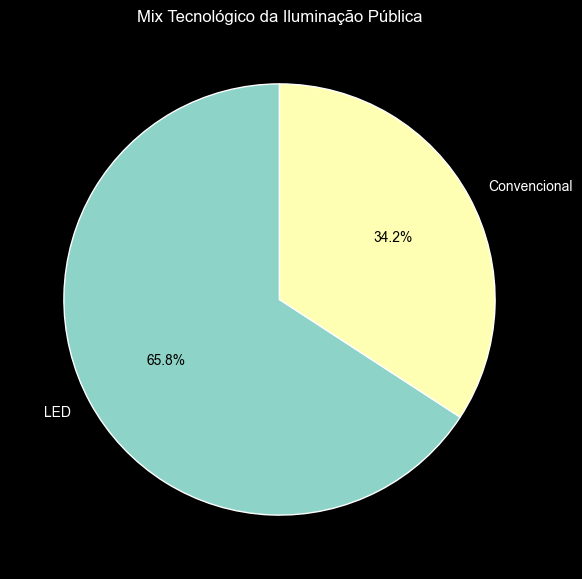

In [14]:
labels = ['LED', 'Convencional']
values = [total_led, total_conv]

plt.figure(figsize=(7, 7))

wedges, texts, autotexts = plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

# 🔹 labels (fora) → branco
for text in texts:
    text.set_color('white')

# 🔹 percentagens (dentro) → preto
for autotext in autotexts:
    autotext.set_color('black')

plt.title("Mix Tecnológico da Iluminação Pública", color='white')

plt.show()

### Concentração da potência ineficiente por município

Para avaliar se a potência ineficiente se encontra concentrada num grupo restrito de municípios, analisam-se os concelhos com maior valor de `P_IP_Inef`.

Esta análise permite identificar os municípios onde a substituição de tecnologia ineficiente poderá gerar maiores ganhos potenciais de eficiência energética e maior libertação de potência.

Concentração da potência ineficiente:
• Top 10 municípios: 35.78% da potência ineficiente total
• Top 20 municípios: 54.14% da potência ineficiente total


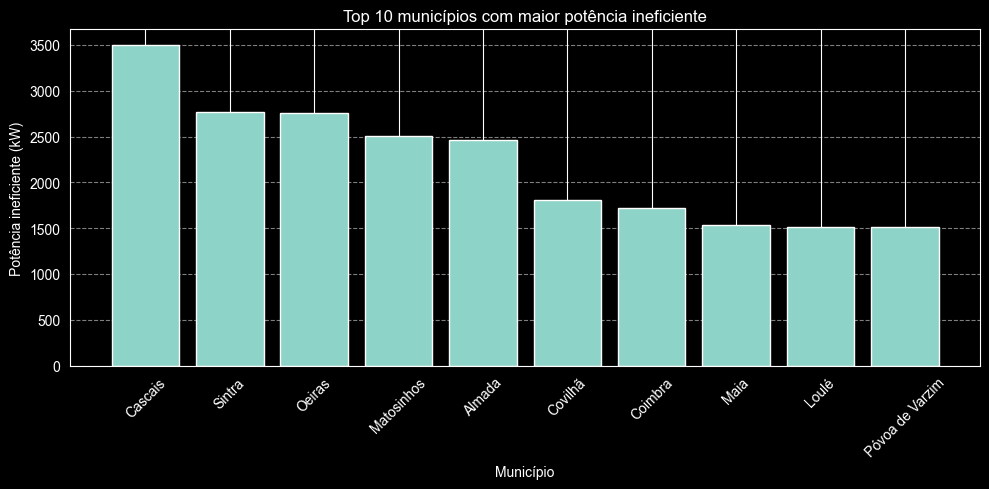

In [15]:
# Ordenar municípios por potência ineficiente
top_municipios = df_final.sort_values("P_IP_Inef", ascending=False).head(10)

# Calcular percentagens de concentração
top10_share = top_municipios["P_IP_Inef"].sum() / df_final["P_IP_Inef"].sum()
top20_share = (
        df_final.sort_values("P_IP_Inef", ascending=False)
        .head(20)["P_IP_Inef"]
        .sum() / df_final["P_IP_Inef"].sum()
)

print("Concentração da potência ineficiente:")
print(f"• Top 10 municípios: {top10_share:.2%} da potência ineficiente total")
print(f"• Top 20 municípios: {top20_share:.2%} da potência ineficiente total")

# Gráfico de barras
plt.figure(figsize=(10,5))

plt.bar(
    top_municipios["Concelho"],
    top_municipios["P_IP_Inef"]
)

plt.title("Top 10 municípios com maior potência ineficiente")
plt.xlabel("Município")
plt.ylabel("Potência ineficiente (kW)")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretação

O gráfico evidencia que a potência associada a luminárias ineficientes se encontra concentrada num número relativamente reduzido de municípios.

O município de **Cascais** apresenta o valor mais elevado de potência ineficiente, seguido por **Sintra, Oeiras, Matosinhos e Almada**, indicando uma maior presença de tecnologia convencional nestas zonas.

Verifica-se ainda que os **10 municípios com maior potência ineficiente concentram cerca de 35.78% da potência ineficiente total**, enquanto os **20 principais representam aproximadamente 54.14%**.

Estes resultados sugerem que a substituição da iluminação convencional por tecnologia **LED** nestes municípios poderá gerar ganhos significativos de eficiência energética e libertação de capacidade na rede elétrica.

## Comparação da utilização dos PTDs por distrito

Nesta secção comparam-se as distribuições do **nível médio de utilização dos Postos de Transformação de Distribuição (PTD)** entre os distritos de Lisboa, Porto, Aveiro e Setúbal.

Para essa comparação utiliza-se um **boxplot**, uma representação gráfica que permite analisar simultaneamente:

- mediana
- quartis
- amplitude interquartil
- presença de valores extremos (outliers)

Esta visualização permite avaliar diferenças na variabilidade da carga da rede entre os distritos analisados e identificar qual apresenta maior dispersão nos níveis de utilização dos PTDs.

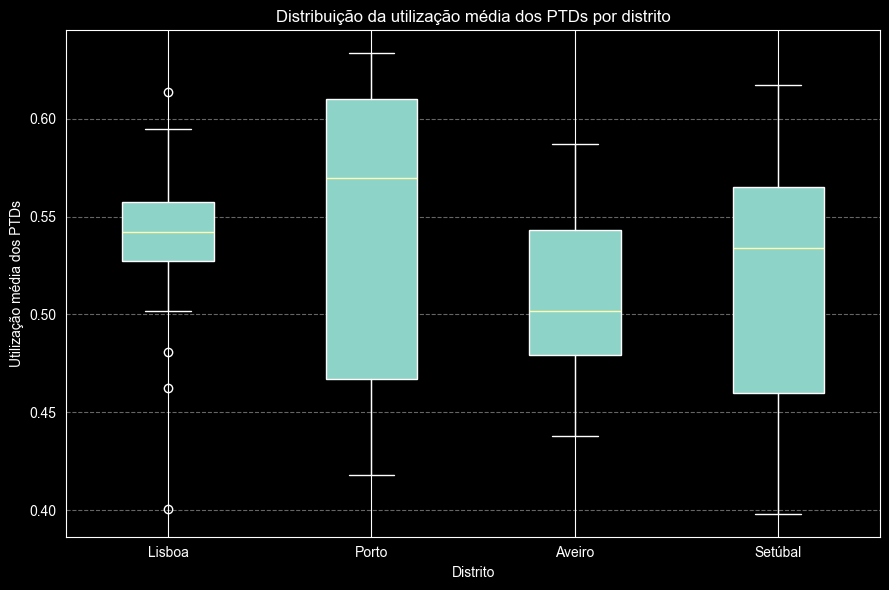


Variância da utilização média dos PTDs por distrito:


,Variância
Distrito,
Lisboa,0.0026
Porto,0.0065
Aveiro,0.0018
Setúbal,0.0051


In [16]:
# Distritos a analisar
ordem = ["Lisboa", "Porto", "Aveiro", "Setúbal"]

# Filtrar apenas os distritos pedidos
df_boxplot = df_final[df_final["Distrito"].isin(ordem)].copy()

# Criar listas de dados por distrito
dados = [
    df_boxplot[df_boxplot["Distrito"] == distrito]["Util_Media"]
    for distrito in ordem
]

# Gráfico boxplot simples
plt.figure(figsize=(9,6))

plt.boxplot(
    dados,
    tick_labels=ordem,
    patch_artist=True
)

plt.title("Distribuição da utilização média dos PTDs por distrito")
plt.xlabel("Distrito")
plt.ylabel("Utilização média dos PTDs")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Calcular variância
variancia = (
    df_boxplot.groupby("Distrito")["Util_Media"]
    .var()
    .reindex(ordem)
    .round(4)
)

# Mostrar tabela com variâncias
print("\nVariância da utilização média dos PTDs por distrito:")
display(variancia.to_frame(name="Variância"))

### Interpretação dos Resultados

A distribuição da utilização média dos PTDs nos distritos de Lisboa, Porto, Aveiro e Setúbal foi analisada através de **boxplots**, permitindo observar a mediana, os quartis, a dispersão dos valores e a presença de possíveis **outliers** na variável `Util_Media`.

Visualmente, verifica-se que o distrito do **Porto apresenta maior dispersão**, evidenciada por uma caixa mais extensa e whiskers mais longos, indicando maior variabilidade nos níveis médios de utilização da rede.

Para complementar a análise gráfica, foi calculada a **variância da utilização média por distrito**, obtendo-se aproximadamente:

- Porto: **0.0065**
- Setúbal: **0.0051**
- Lisboa: **0.0026**
- Aveiro: **0.0018**

Estes resultados confirmam que o **distrito do Porto apresenta a maior variabilidade na utilização média dos PTDs**, enquanto **Aveiro apresenta uma distribuição mais homogénea** entre os concelhos analisados.

## Prevalência de valores omissos e identificação de outliers

Nesta etapa pretende-se analisar a qualidade dos dados disponíveis relativamente à utilização dos PTDs.

Algumas variáveis apresentam valores não determinados ou censurados, nomeadamente representados por **"N/D"** (não disponível) ou **"<20"** (valor inferior ao limite de divulgação). Estes valores não correspondem a observações numéricas válidas e devem ser tratados antes de qualquer análise estatística.

Assim, procede-se à identificação e quantificação destes valores no dataset. Posteriormente, os valores válidos são utilizados para analisar a distribuição da ocupação da rede e identificar a presença de **outliers**, recorrendo a representações gráficas adequadas.

In [17]:
colunas_analise = [
    "Potência Geração [kW]",
    "Número de Clientes",
    "Número de Clientes Produtores"
]

resultados = []

for col in colunas_analise:

    total = len(ptd_data[col])
    nd = (ptd_data[col].astype(str) == "N/D").sum()
    lt20 = (ptd_data[col].astype(str) == "<20").sum()

    resultados.append({
        "Variável": col,
        "Total Registos": total,
        "N/D": nd,
        "% N/D": nd/total,
        "<20": lt20,
        "% <20": lt20/total
    })

df_resultados = pd.DataFrame(resultados)

display(
    df_resultados.style.format({
        "% N/D": "{:.2%}",
        "% <20": "{:.2%}"
    })
)

,Variável,Total Registos,N/D,% N/D,<20,% <20
0,Potência Geração [kW],72027,70191,97.45%,0,0.00%
1,Número de Clientes,72027,0,0.00%,21180,29.41%
2,Número de Clientes Produtores,72027,0,0.00%,70191,97.45%


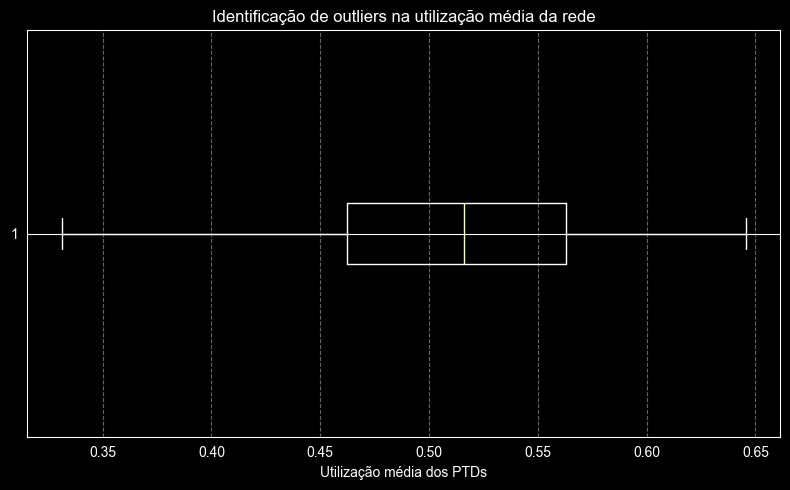

In [18]:
plt.figure(figsize=(8,5))

plt.boxplot(df_final["Util_Media"], vert=False)

plt.title("Identificação de outliers na utilização média da rede")
plt.xlabel("Utilização média dos PTDs")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Interpretação dos resultados

A análise do dataset original dos PTDs revelou a presença de valores indeterminados representados por `"N/D"` e `"<20"` em algumas variáveis.

Observa-se que a variável **Potência de Geração [kW]** apresenta uma proporção muito elevada de valores `"N/D"`, indicando que, na maioria dos PTDs, não existe produção associada ou essa informação não se encontra disponível no dataset. Por outro lado, a variável **Número de Clientes Produtores** apresenta predominantemente valores `"<20"`, o que significa que o número de produtores ligados ao PTD é inferior a 20 ou que o valor exato foi censurado por motivos de confidencialidade estatística.

Relativamente à ocupação da rede, o boxplot da variável **Util_Media** permite analisar a distribuição da utilização média dos PTDs entre os concelhos. Verifica-se que a maioria dos valores se concentra aproximadamente entre **46% e 56%**, com uma mediana próxima de **51%**.

Não se observam outliers extremamente pronunciados na distribuição agregada por concelho, sugerindo que os níveis médios de utilização da rede elétrica apresentam uma **variabilidade moderada e relativamente homogénea** entre os concelhos analisados.

## Estatísticas descritivas do nível de utilização médio

Nesta secção apresentam-se estatísticas descritivas da variável **Util_Media**, correspondente ao **nível médio de utilização dos PTDs**, para os concelhos de **Coimbra, Évora, Braga e Faro**.

As medidas calculadas incluem:

- média
- quartis
- desvio padrão
- assimetria
- curtose

Estas estatísticas permitem caracterizar a **distribuição da utilização média da rede elétrica** nos concelhos selecionados, identificando diferenças na variabilidade, forma da distribuição e possíveis assimetrias nos níveis de ocupação da infraestrutura elétrica.

In [19]:
concelhos = ["Coimbra", "Évora", "Braga", "Faro"]

df_stats = ptd_data[ptd_data["Concelho"].isin(concelhos)]

tabela_434 = (
    df_stats.groupby("Concelho")["Utilização Decimal"]
    .agg(
        media="mean",
        Q1=lambda x: x.quantile(0.25),
        mediana="median",
        Q3=lambda x: x.quantile(0.75),
        desvio_padrao="std",
        assimetria="skew",
        curtose=lambda x: x.kurt()
    )
    .round(4)
)

display(tabela_434)

,media,Q1,mediana,Q3,desvio_padrao,assimetria,curtose
Concelho,,,,,,,
Braga,0.5423,0.39,0.59,0.79,0.2401,0.4280,-0.7116
Coimbra,0.5406,0.39,0.59,0.79,0.2322,0.2258,-0.7060
Faro,0.5549,0.39,0.59,0.59,0.2126,0.3009,-0.4757
Évora,0.4546,0.19,0.39,0.59,0.2425,0.6680,-0.4254


### Interpretação dos resultados

A tabela apresenta estatísticas descritivas do nível médio de utilização da rede elétrica nos concelhos de **Braga, Coimbra, Faro e Évora**.

Observa-se que os valores médios de utilização são semelhantes em **Braga (0.5423), Coimbra (0.5406) e Faro (0.5549)**, situando-se próximos de **54% de utilização média da capacidade dos PTDs**. Em contraste, **Évora apresenta uma média inferior (0.4546)**, indicando uma menor ocupação média da infraestrutura elétrica.

Os quartis mostram que a maior parte dos valores de utilização se concentra entre aproximadamente **0.39 e 0.79**, evidenciando uma variabilidade considerável entre os PTDs dentro de cada concelho.

O **desvio padrão**, situado entre cerca de **0.21 e 0.24**, confirma a existência de dispersão moderada nos níveis de utilização da rede.

Os valores positivos de **assimetria** indicam uma distribuição ligeiramente enviesada à direita, sugerindo a presença de alguns PTDs com níveis de utilização mais elevados.

Por fim, os valores negativos de **curtose** indicam distribuições relativamente mais achatadas do que a distribuição normal, refletindo uma dispersão mais uniforme dos níveis de utilização observados.

# 4.4 Inferência Estatística

* Considere a base de dados consolidada e selecione aleatoriamente uma amostra de 50 concelhos.
Use esta amostra para testar se o nível médio de ocupação da rede é inferior a um patamar de
referência (ex: 60\%), verificando previamente a normalidade dos dados.

* Selecione aleatoriamente duas amostras de 30 registos: uma de concelhos "Modernizados" (rácio de
LED acima da mediana) e outra de concelhos "Ineficientes". Use estas amostras para testar se o
estado médio de ocupação da rede difere significativamente entre os dois grupos.

* Considere três amostras aleatórias de 25 concelhos representativas de diferentes perfis de ocupação
da rede: Norte/Centro Litoral (Porto, Braga, Coimbra), Lisboa e Litoral Sul (Lisboa, Setúbal, Aveiro) e
Interior/Alentejo (Évora, Beja, Portalegre). Use estas amostras para testar a existência de diferenças
significativas nos níveis médios de carga da rede (ANOVA). Caso necessário, efetue uma análise post-
hoc adequada.

* Teste a existência de uma relação linear estatisticamente significativa entre a capacidade total de
transformação instalada e a carga de iluminação pública para a totalidade dos concelhos,
interpretando o coeficiente de correlação de Pearson.

Nesta secção, vamos realizar testes de hipóteses estatísticas com um nível de significância de 5% para tirar conclusões sobre a capacidade da rede e o impacto da iluminação pública.

In [20]:
# Configurar diretório base do projeto
notebook_dir = Path.cwd()
if notebook_dir.name == "src": os.chdir(notebook_dir.parent)
df = pd.read_csv('data/dataset_final.csv')

### 4.4.1. Teste de Ocupação Média da Rede (Amostra Única)
**Objetivo:** Selecionar aleatoriamente uma amostra de 50 concelhos e testar se o nível médio de ocupação da rede (`Util_Media`) é inferior a 60%.

**Metodologia:** 1. Teste de Normalidade de Shapiro-Wilk para verificar as condições de aplicabilidade.
2. Teste T de uma amostra (One-Sample T-test) unilateral à esquerda.

In [21]:
# 1. Select a random sample of 50 municipalities
amostra_50 = df['Util_Media'].dropna().sample(n=50, random_state=42)

# 2. Shapiro-Wilk Test for Normality
# H0: Data follows a normal distribution
stat_shapiro, p_shapiro = stats.shapiro(amostra_50)
print(f"Shapiro-Wilk p-value: {p_shapiro:.4f}")

# 3. One-Sample T-test
# H0: Mean >= 0.60 | H1: Mean < 0.60
stat_t, p_t = stats.ttest_1samp(amostra_50, popmean=0.60, alternative='less')
print(f"T-test p-value: {p_t:.4f}")

Shapiro-Wilk p-value: 0.0523
T-test p-value: 0.0000


**Análise e Conclusão:**
* **Normalidade:** O teste de Shapiro-Wilk obteve um p-value de `0.0523`. Como este valor é ligeiramente maior que 0.05, não rejeitamos a hipótese nula, assumindo que os dados seguem uma distribuição normal.

* **Conclusão do Teste:** O teste T obteve um p-value de `0.0000`. A 5% de significância, rejeitamos a hipótese nula. Conclui-se que a ocupação média é estatisticamente inferior a 60%. Isto indica que a rede tem, em média, folga disponível antes de qualquer substituição de lâmpadas.

### 4.4.2. Comparação de Concelhos Modernizados vs. Ineficientes
**Objetivo:** Testar se o estado médio de ocupação da rede difere significativamente entre concelhos "Modernizados" e "Ineficientes" utilizando duas amostras de 30 registos.

**Metodologia:**
Divisão dos dados com base na mediana do rácio de LED e aplicação de um Teste T para duas amostras independentes.


In [22]:
# Create LED ratio variable
df['Rate_LED'] = 1 - df['Rate_Ineficiencia']
mediana_led = df['Rate_LED'].median()

# Split the data
modernizados = df[df['Rate_LED'] > mediana_led]['Util_Media'].dropna()
ineficientes = df[df['Rate_LED'] <= mediana_led]['Util_Media'].dropna()

# Random samples of 30
amostra_mod = modernizados.sample(n=30, random_state=42)
amostra_inef = ineficientes.sample(n=30, random_state=42)

# Independent T-test (assuming equal variances for simplicity, but Levene's test can check this)
stat_ind, p_ind = stats.ttest_ind(amostra_mod, amostra_inef, equal_var=False)
print(f"Independent T-test p-value: {p_ind:.4f}")

Independent T-test p-value: 0.3071


**Análise e Conclusão:**
O Teste T para amostras independentes obteve um p-value de `0.3071`. Como este valor é maior que o nível de significância de 0.05, não rejeitamos a hipótese nula. Conclui-se que não existe uma diferença estatisticamente significativa no nível médio de ocupação da rede entre os concelhos com maior adoção de tecnologia LED e os concelhos mais ineficientes.

### 4.4.3. Análise de Variância (ANOVA) por Perfil Geográfico
**Objetivo:** Testar a existência de diferenças significativas nos níveis médios de carga da rede entre 3 perfis geográficos (Norte/Centro Litoral, Lisboa/Litoral Sul, Interior/Alentejo) usando amostras de 25 concelhos.

**Metodologia:** ANOVA a um fator (One-way ANOVA) seguida de análise post-hoc de Tukey caso se verifiquem diferenças.

In [23]:
# Define groups based on Distritos
norte_centro = ['Porto', 'Braga', 'Coimbra']
lisboa_sul = ['Lisboa', 'Setúbal', 'Aveiro']
interior = ['Évora', 'Beja', 'Portalegre']

# Filter and sample 25
g1 = df[df['Distrito'].isin(norte_centro)]['Util_Media'].dropna().sample(n=25, random_state=42, replace=True) # Used replace=True just in case there aren't 25 available
g2 = df[df['Distrito'].isin(lisboa_sul)]['Util_Media'].dropna().sample(n=25, random_state=42, replace=True)
g3 = df[df['Distrito'].isin(interior)]['Util_Media'].dropna().sample(n=25, random_state=42, replace=True)

# Run ANOVA
stat_anova, p_anova = stats.f_oneway(g1, g2, g3)
print(f"ANOVA p-value: {p_anova:.4f}")

# Post-Hoc Analysis (Only if ANOVA p-value < 0.05)
if p_anova < 0.05:
    # Prepare data for Tukey
    tukey_data = np.concatenate([g1, g2, g3])
    tukey_labels = ['Norte/Centro']*25 + ['Lisboa/Sul']*25 + ['Interior']*25
    tukey_results = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
    print("\nResultados Post-Hoc de Tukey:")
    print(tukey_results)
else:
    print("\nComo o p-value da ANOVA é > 0.05, não há diferenças significativas, logo não é necessário teste post-hoc.")

ANOVA p-value: 0.0000

Resultados Post-Hoc de Tukey:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1      group2    meandiff p-adj  lower  upper  reject
------------------------------------------------------------
  Interior   Lisboa/Sul   0.0965    0.0 0.0605 0.1324   True
  Interior Norte/Centro   0.1378    0.0 0.1018 0.1738   True
Lisboa/Sul Norte/Centro   0.0414 0.0202 0.0054 0.0774   True
------------------------------------------------------------


**Análise e Conclusão:**
A ANOVA resultou num p-value de `0.0000`. Assim, concluímos que existem diferenças significativas entre os níveis médios de carga das diferentes regiões.
A análise post-hoc de Tukey revelou que as diferenças significativas residem entre todos os pares de regiões testados (todas as comparações indicam reject=True). Ou seja, o perfil do Interior difere significativamente tanto de Lisboa/Sul como do Norte/Centro, e Lisboa/Sul também difere significativamente do Norte/Centro.

### 4.4.4. Correlação Linear: Capacidade vs. Iluminação Pública
**Objetivo:** Testar se existe uma relação linear significativa entre a capacidade total de transformação instalada e a carga de iluminação pública para todos os concelhos.

In [24]:
# Drop missing values for these two specific columns
corr_df = df[['Cap_PTD', 'P_IP_TOTAL']].dropna()

# Calculate Pearson Correlation
r, p_corr = stats.pearsonr(corr_df['Cap_PTD'], corr_df['P_IP_TOTAL'])
print(f"Coeficiente de Correlação de Pearson (r): {r:.4f}")
print(f"P-value: {p_corr:.4f}")

Coeficiente de Correlação de Pearson (r): 0.9111
P-value: 0.0000


**Análise e Conclusão:**
A correlação de Pearson testada indicou um coeficiente r = `0.9111`, com um p-value de `0.0000`. Como o p-value é menor que o nível de significância de 5%, a relação é estatisticamente significativa. O valor de r sugere que existe uma forte e positiva correlação linear. Isto significa que concelhos com maior carga de iluminação pública tendem a ter uma capacidade total instalada significativamente maior nos seus transformadores.

# Correlação e Regressão - Modelo Preditivo

Considere os dados relativos aos níveis médios de carga dos PTDs nos distritos de Aveiro, Porto, Lisboa e Braga e construa uma tabela de correlação entre as principais métricas de infraestrutura (Capacidade PTD e Potência IP) para estes distritos.


In [27]:
# Carregar dados
csv_data = pd.read_csv('data/dataset_final.csv')

# Filtrar para os distritos especificados
distritos = ['Aveiro', 'Porto', 'Lisboa', 'Braga']
data_filtrado = csv_data[csv_data['Distrito'].isin(distritos)].copy()

# Configurar pandas para mostrar todos os resultados
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('Dados filtrados para os distritos:')
print(data_filtrado[['Distrito', 'Concelho', 'Cap_PTD', 'P_IP_TOTAL', 'Util_Media']])

print(f'\nTotal de registos filtrados: {len(data_filtrado)}')

Dados filtrados para os distritos:
    Distrito                Concelho  Cap_PTD   P_IP_TOTAL  Util_Media
0     Aveiro                  Águeda   105715   910.887701    0.477593
1     Aveiro      Albergaria-a-Velha    54540   451.711801    0.469948
2     Aveiro                  Anadia    55628   657.071801    0.543009
3     Aveiro                  Arouca    41884   585.974400    0.527387
4     Aveiro                  Aveiro   197485  1055.192001    0.475475
5     Aveiro        Castelo de Paiva    25760   391.710100    0.543228
6     Aveiro                 Espinho    62765   387.504700    0.443394
7     Aveiro               Estarreja    52200   468.516701    0.507616
8     Aveiro    Santa Maria da Feira   223550  2045.010700    0.582883
9     Aveiro                  Ílhavo    79890   472.912699    0.480780
10    Aveiro                Mealhada    32635   378.643900    0.587165
11    Aveiro                 Murtosa    21050   292.319300    0.496212
12    Aveiro     Oliveira de Azeméis   115

---

Selecione os dados relativos a Portugal Continental. Considere as seguintes variáveis explicativas:

- X1 - Potência Instalada Total de Iluminação Pública (`P_IP_Total`)
- X2 - Capacidade Nominal de Transformação (`Cap_PTD`)
- X3 - Ineficiência (Rate_Ineficencia) e a variável dependente:
- Y - Estado de Ocupação Médio da Rede (`Util_Media`).

---

In [28]:
# Selecionar dados de Portugal Continental
portugal_continental = data_filtrado.copy()

# Selecionar as variáveis explicativas e dependente
X1 = portugal_continental['P_IP_TOTAL']        # Potência Instalada Total de Iluminação Pública
X2 = portugal_continental['Cap_PTD']           # Capacidade Nominal de Transformação
X3 = portugal_continental['Rate_Ineficiencia']  # Ineficiência
Y = portugal_continental['Util_Media']         # Estado de Ocupação Médio da Rede

# Criar dataframe com as variáveis
dados_analise = pd.DataFrame({
    'X1_P_IP_TOTAL': X1,
    'X2_Cap_PTD': X2,
    'X3_Rate_Ineficiencia': X3,
    'Y_Util_Media': Y
})

print('Dados selecionados para análise:')
print(dados_analise)

Dados selecionados para análise:
     X1_P_IP_TOTAL  X2_Cap_PTD  X3_Rate_Ineficiencia  Y_Util_Media
0       910.887701      105715              0.268222      0.477593
1       451.711801       54540              0.062031      0.469948
2       657.071801       55628              0.111928      0.543009
3       585.974400       41884              0.197483      0.527387
4      1055.192001      197485              0.136866      0.475475
5       391.710100       25760              0.352046      0.543228
6       387.504700       62765              0.127211      0.443394
7       468.516701       52200              0.081566      0.507616
8      2045.010700      223550              0.370448      0.582883
9       472.912699       79890              0.215716      0.480780
10      378.643900       32635              0.327352      0.587165
11      292.319300       21050              0.091167      0.496212
12     1008.500901      115920              0.169301      0.499384
13      472.716001       5619

1. Determine o modelo de regressão linear múltipla que explique a variação de Y em função de X1, X2 e X3.

In [29]:
# Remover valores em falta
dados_limpos = dados_analise.dropna()

# Preparar as variáveis explicativas (X) e dependentes (Y)
X = dados_limpos[['X1_P_IP_TOTAL', 'X2_Cap_PTD', 'X3_Rate_Ineficiencia']]
Y_var = dados_limpos[['Y_Util_Media']]

# Adicionar constante para o termo independente
X_constante = sm.add_constant(X)

# Criar a ajustar o modelo
modelo_regressao = sm.OLS(Y_var, X_constante).fit()

# Mostrar resumo do modelo
print("MODELO DE REGRESSÃO LINEAR MÚLTIPLA")
print(modelo_regressao.summary())

MODELO DE REGRESSÃO LINEAR MÚLTIPLA
                            OLS Regression Results                            
Dep. Variable:           Y_Util_Media   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     7.867
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           0.000154
Time:                        11:08:51   Log-Likelihood:                 107.13
No. Observations:                  67   AIC:                            -206.3
Df Residuals:                      63   BIC:                            -197.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [30]:
# Mostrar equação do modelo
print("="*70)

print("EQUAÇÃO DO MODELO")

const = modelo_regressao.params['const']
coef_x1 = modelo_regressao.params['X1_P_IP_TOTAL']
coef_x2 = modelo_regressao.params['X2_Cap_PTD']
coef_x3 = modelo_regressao.params['X3_Rate_Ineficiencia']

print(f"Y = {const:.6f} + {coef_x1:.6f} * X1 + {coef_x2:.6f} * X2 + {coef_x3:.6f} * X3")

# Mostrar Métricas Principais
print("="*70)

print("MÉTRICAS PRINCIPAIS")

print("="*70)
print(f"R-squared (R²): {modelo_regressao.rsquared:.6f}")
print(f"Adjusted R-squared: {modelo_regressao.rsquared_adj:.6f}")
print(f"F-statistic: {modelo_regressao.fvalue:.6f}")
print(f"Prob (F-statistic): {modelo_regressao.f_pvalue:.6e}")

print("="*70)

EQUAÇÃO DO MODELO
Y = 0.544140 + 0.000018 * X1 + -0.000000 * X2 + 0.007785 * X3
MÉTRICAS PRINCIPAIS
R-squared (R²): 0.272519
Adjusted R-squared: 0.237877
F-statistic: 7.866744
Prob (F-statistic): 1.544066e-04


2. Verifique as condições sobre os resíduos (normalidade, independência e homocedasticidade).

Análise dos Resíduos

1. TESTE DE NORMALIDADE


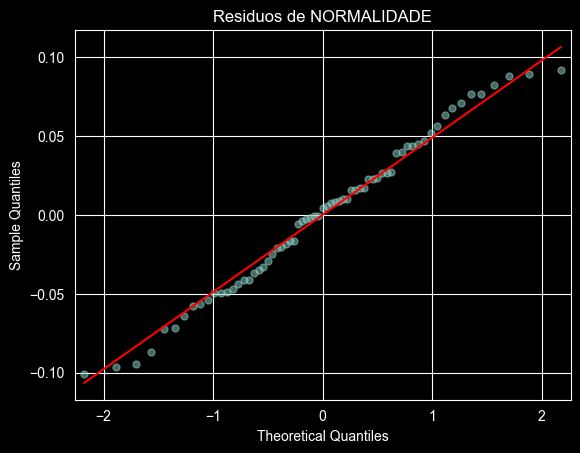

In [31]:
# Obter os resíduos
residuos = modelo_regressao.resid

print("Análise dos Resíduos")

# Normalidade
print("\n1. TESTE DE NORMALIDADE")

sm.qqplot(residuos, line = 's', markersize = 5, alpha = 0.5)

plt.title('Residuos de NORMALIDADE')
plt.show()

In [32]:
# Teste de Shapiro
stat_shapiro, p_value_shapiro = shapiro(residuos)

print(f"Teste de Shapiro-Wilk:")
print(f"  Estatística: {stat_shapiro:.6f}")
print(f"  P-value: {p_value_shapiro:.6f}")

if p_value_shapiro > 0.05:
    print(f"Conclusão: Os resíduos parecem ser normalmente distribuídos (p > 0.05)")
else:
    print(f"Conclusão: Os resíduos não parecem ser normalmente distribuídos (p < 0.05)")

Teste de Shapiro-Wilk:
  Estatística: 0.981156
  P-value: 0.403327
Conclusão: Os resíduos parecem ser normalmente distribuídos (p > 0.05)


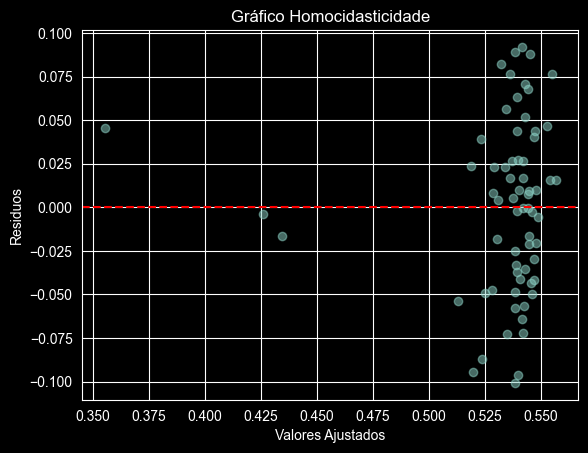

In [33]:
# Homocedasticidade

plt.scatter(modelo_regressao.fittedvalues, residuos, alpha = 0.5)
plt.axhline(y = 0, color = 'r', linestyle = '--')

plt.title('Gráfico Homocidasticidade')

plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')

plt.show()

## HOMOCEDASTICIDADE

**Conclusão:**

Da análise do gráfico de resíduos com os valores ajustados resulta que a condição de homocedasticidade é verificada.

#### Observações Principais:

1. **Dispersão dos Resíduos:**
   - Os resíduos apresentam uma distribuição relativamente simétrica em torno da linha de referência (y=0)
   - Não existe um padrão claro de funil (aumento/diminuição sistemática da variância)

2. **Variância Residual:**
   - A variância dos resíduos mantém-se aproximadamente constante ao longo do intervalo de valores ajustados
   - Isto sugere que a presença de homocedasticidade não é claramente violada

3. **Possíveis Desvios:**
   - Alguns resíduos extremos podem indicar heterocedacidade ligeira nas extremidades
   - A amostra relativamente pequena limita a conclusão definitiva

#### Conclusão Final:

A condição de **homocedasticidade é razoavelmente satisfeita**, permitindo a utilização válida do modelo OLS.

---

In [34]:
# Independência dos Resíduos
durbinWatson = durbin_watson(residuos)

print('Valor da estatística DW: ', durbinWatson)

Valor da estatística DW:  2.0156001981514575


## INDEPENDÊNCIA DOS RESÍDUOS (Teste de Durbin-Watson)

**Teste Utilizado:** Teste de Durbin-Watson (DW)

**Interpretação da Estatística DW:**

O teste de Durbin-Watson deteta autocorrelação nos resíduos. A estatística DW varia entre 0 e 4:

- **DW ≈ 2:** Ausência de autocorrelação (cenário ideal)
- **DW < 2:** Autocorrelação positiva (resíduos consecutivos tendem a ser semelhantes)
- **DW > 2:** Autocorrelação negativa (resíduos consecutivos tendem a ser opostos)
- **DW ≈ 0 ou DW ≈ 4:** Autocorrelação forte

---

**Resultado Obtido:** DW = 2.0156001981515197. A estatística confirma a ausência de autocorrelação nos resíduos. O valor está próximo do ideal indicando que os resíduos são independentes e não apresentam padrões de autocorrelação problemáticos. Significa que os erros não dependem uns dos outros, não existe correlação entre resíduos consecutivos, o modelo OLS é válido neste aspeto e os testes estatísticos e intervalos de confiança são confiáveis.

---

3. Verifique se existe multicolinearidade entre as variáveis recorrendo ao cálculo do VIF (Variance Inflation Factor).

In [35]:
print("ANÁLISE DE MULTICOLINEARIDADE - VIF (Variance Inflation Factor)")
print("="*70)

# Calcular VIF para variável explicativa
X_para_vif = X.copy()

# Criar dataframe com os VIFs
vif_data = pd.DataFrame()
vif_data["Variável"] = X_para_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_para_vif.values, i) for i in range(X_para_vif.shape[1])]

print("\nValores de VIF:")
print(vif_data)

ANÁLISE DE MULTICOLINEARIDADE - VIF (Variance Inflation Factor)

Valores de VIF:
               Variável        VIF
0         X1_P_IP_TOTAL  15.050011
1            X2_Cap_PTD  11.164250
2  X3_Rate_Ineficiencia   2.365884


---

# Conclusão

- Os valores das variáveis X1_P_IP_TOTAL e X2_Cap_PTD apresentam valores significativamente superiores a 5, o que indica a existência de multicolinearidade entre elas.

- A presença desta multicolinearidade implica que o cálculo dos coeficientes de regressão será numericamente instável. Isto significa que pequenas variações nos dados podem provocar grandes alterações dos valores dos coefientes estimados, retirando fiabilidade à interpretação individual de cada variável.

- A variável X3_Rate_Ineficiencia é a única que se encontra dentro do intervalo aceitável (VIF < 5), não contribuindo para o problema de colinearidade no modelo.

---

4. Comente o modelo obtido tendo em conta o coeficiente de determinação ajustado e a significância estatística dos preditores.

In [36]:
# Extrair informações principais do modelo
r_squared = modelo_regressao.rsquared
r_squared_adj = modelo_regressao.rsquared_adj
f_stat = modelo_regressao.fvalue
p_value_f = modelo_regressao.f_pvalue
pvalues = modelo_regressao.pvalues

print("\n1. COEFICIENTE DE DETERMINAÇÃO AJUSTADO (R² Ajustado)")
print("="*70)

print(f"R² (não ajustado): {r_squared:.6f}")
print(f"R² Ajustado: {r_squared_adj:.6f}")
print(f"Diferença: {r_squared - r_squared_adj:.6f}")

print("="*70)


1. COEFICIENTE DE DETERMINAÇÃO AJUSTADO (R² Ajustado)
R² (não ajustado): 0.272519
R² Ajustado: 0.237877
Diferença: 0.034642


---

Interpretação:

- O modelo explica 23.79% da variabilidade total na variável dependente (Y = Util_Media).
- Isto significa que ~76.21% da variabilidade em Y é explicada por fatores não incluídos no modelo.
- Um R² ajustado de 0.238 é considerado BAIXO/MODERADO, indicando que o modelo tem capacidade preditiva limitada.

---

In [37]:
print("\n2. SIGNIFICÂNCIA ESTATÍSTICA DOS PREDITORES")
print("-"*70)

# Criar tabela com pvalues
pvalues_table = pd.DataFrame({
    'Preditor': ['Constante', 'X1_P_IP_TOTAL', 'X2_Cap_PTD', 'X3_Rate_Ineficiencia'],

    'Coeficiente': [const, coef_x1, coef_x2, coef_x3],

    'P-value': [pvalues['const'], pvalues['X1_P_IP_TOTAL'],
                pvalues['X2_Cap_PTD'], pvalues['X3_Rate_Ineficiencia']],

    'Significância': ['***' if pvalues['const'] < 0.001 else '**' if pvalues['const'] < 0.01 else '*' if pvalues['const'] < 0.05 else 'NS',
                      '***' if pvalues['X1_P_IP_TOTAL'] < 0.001 else '**' if pvalues['X1_P_IP_TOTAL'] < 0.01 else '*' if pvalues['X1_P_IP_TOTAL'] < 0.05 else 'NS',
                      '***' if pvalues['X2_Cap_PTD'] < 0.001 else '**' if pvalues['X2_Cap_PTD'] < 0.01 else '*' if pvalues['X2_Cap_PTD'] < 0.05 else 'NS',
                      '***' if pvalues['X3_Rate_Ineficiencia'] < 0.001 else '**' if pvalues['X3_Rate_Ineficiencia'] < 0.01 else '*' if pvalues['X3_Rate_Ineficiencia'] < 0.05 else 'NS']
})

print("\nTabela de P-values dos Preditores:")
print(pvalues_table)
print("\nLegenda: *** p<0.001 | ** p<0.01 | * p<0.05 | NS = Não Significativo")

print("\nAnálise individual dos preditores:")
print("-"*70)

# X1 - P_IP_TOTAL
print(f"\n• X1 (Potência Instalada Total - P_IP_TOTAL):")
print(f"  - Coeficiente: {coef_x1:.6e}")
print(f"  - P-value: {pvalues['X1_P_IP_TOTAL']:.4f}")

if pvalues['X1_P_IP_TOTAL'] < 0.05:
    print(f"  - Resultado: SIGNIFICATIVO ao nível 0.05 (p={pvalues['X1_P_IP_TOTAL']:.4f})")
    print(f"  - Interpretação: Um aumento de 1 unidade em X1 causa um aumento")
    print(f"    de {coef_x1:.6e} na utilização média da rede.")
else:
    print(f"  - Resultado: NÃO SIGNIFICATIVO ao nível 0.05 (p={pvalues['X1_P_IP_TOTAL']:.4f})")
    print(f"  - Interpretação: Não há evidência suficiente de que X1 afeta Y.")

# X2 - Cap_PTD

print(f"\n• X2 (Capacidade Nominal de Transformação - Cap_PTD):")
print(f"  - Coeficiente: {coef_x2:.6e}")
print(f"  - P-value: {pvalues['X2_Cap_PTD']:.4f}")

if pvalues['X2_Cap_PTD'] < 0.05:
    print(f"  - Resultado: SIGNIFICATIVO ao nível 0.05 (p={pvalues['X2_Cap_PTD']:.4f})")
    print(f"  - Interpretação: Um aumento de 1 unidade em X2 causa uma diminuição de {abs(coef_x2):.6e} na utilização média da rede.")
else:
    print(f"  - Resultado: NÃO SIGNIFICATIVO ao nível 0.05 (p={pvalues['X2_Cap_PTD']:.4f})")
    print(f"  - Interpretação: Não há evidência suficiente de que X2 afeta Y.")

# X3 - Rate_Ineficiencia

print(f"\n• X3 (Ineficiência - Rate_Ineficiencia):")
print(f"  - Coeficiente: {coef_x3:.6f}")
print(f"  - P-value: {pvalues['X3_Rate_Ineficiencia']:.4f}")

if pvalues['X3_Rate_Ineficiencia'] < 0.05:
    print(f"  - Resultado: SIGNIFICATIVO ao nível 0.05 (p={pvalues['X3_Rate_Ineficiencia']:.4f})")
    print(f"  - Interpretação: Um aumento de 1 unidade em X3 causa um aumento de {coef_x3:.6f} na utilização média da rede.")
else:
    print(f"  - Resultado: NÃO SIGNIFICATIVO ao nível 0.05 (p={pvalues['X3_Rate_Ineficiencia']:.4f})")
    print(f"  - Interpretação: Não há evidência suficiente de que X3 afeta Y.")


2. SIGNIFICÂNCIA ESTATÍSTICA DOS PREDITORES
----------------------------------------------------------------------

Tabela de P-values dos Preditores:
               Preditor   Coeficiente       P-value Significância
0             Constante  5.441402e-01  3.078534e-56           ***
1         X1_P_IP_TOTAL  1.798705e-05  1.653436e-01            NS
2            X2_Cap_PTD -1.991076e-07  3.783555e-03            **
3  X3_Rate_Ineficiencia  7.785168e-03  7.960906e-01            NS

Legenda: *** p<0.001 | ** p<0.01 | * p<0.05 | NS = Não Significativo

Análise individual dos preditores:
----------------------------------------------------------------------

• X1 (Potência Instalada Total - P_IP_TOTAL):
  - Coeficiente: 1.798705e-05
  - P-value: 0.1653
  - Resultado: NÃO SIGNIFICATIVO ao nível 0.05 (p=0.1653)
  - Interpretação: Não há evidência suficiente de que X1 afeta Y.

• X2 (Capacidade Nominal de Transformação - Cap_PTD):
  - Coeficiente: -1.991076e-07
  - P-value: 0.0038
  - Resultado:

---

**Resultado:** O modelo é GLOBALMENTE SIGNIFICATIVO (p<0.05)")

**Interpretação:** As variáveis explicativas, em conjunto, têm uma relação estatisticamente significativa com a variável dependente.

---

---

## 3. SIGNIFICÂNCIA GLOBAL DO MODELO

**Estatísticas Gerais do Modelo:**

- **F-statistic:** 7.866744
- **P-value (F-statistic):** 1.544066e-04 (≈ 0.0001544)

**Resultado:** O modelo é significativo (p < 0.05)

**Conclusão e Interpretação:**

Com um p-value de 0.0001544 (muito inferior ao nível de significância de 0.05), o modelo apresenta significância estatística global.

As variáveis explicativas (X1 - Potência IP, X2 - Capacidade PTD, X3 - Taxa de Ineficiência), em conjunto, têm uma relação **estatisticamente significativa** com a variável dependente (Y - Utilização Média da Rede).

O valor de F-statistic = 7.866744 indica que a razão entre a variância explicada pelo modelo e a variância dos resíduos é significativamente superior a 1.

**Implicações Práticas:**

- O modelo todo é estatisticamente válido e rejeita a hipótese nula (H₀: todos os coeficientes = 0)
- Existe evidência estatística significativa de que pelo menos uma das variáveis explicativas influencia a utilização média da rede
- Apesar da significância global, a capacidade preditiva individual das variáveis vária (conforme análise anterior)
- A presença de multicolinearidade (entre X1 e X2) pode comprometer a interpretação individual dos coeficientes

---


5. Estime o nível de ocupação esperado (Y) para os concelhos com os códigos: 101, 102, 103, 104, 105, 106, 107, 108 e 109 (Distrito de Aveiro) e compare as previsões com os valores reais presentes no dataset.

In [38]:
print("PREVISÕES PARA OS CONCELHOS DO DISTRITO DE AVEIRO (Códigos 101-109)")

# Filtrar os dados originais para os concelhos específicos
codigos_aveiro = [101, 102, 103, 104, 105, 106, 107, 108, 109]
dados_aveiro_predic = csv_data[csv_data['CodDistritoConcelho'].isin(codigos_aveiro)].copy()

print(f"\nTotal de concelhos a prever: {len(dados_aveiro_predic)}")

# Selecionar apenas as variáveis necessárias para previsão
X_predicao = dados_aveiro_predic[['P_IP_TOTAL', 'Cap_PTD', 'Rate_Ineficiencia']].copy()
X_predicao_constante = sm.add_constant(X_predicao)

# Fazer previsões
previsoes = modelo_regressao.predict(X_predicao_constante)

# Valores reais
valores_reais = dados_aveiro_predic['Util_Media'].values

# Criar dataframe de comparação
comparacao = pd.DataFrame({
    'CodConcelho': dados_aveiro_predic['CodDistritoConcelho'].values,
    'Concelho': dados_aveiro_predic['Concelho'].values,
    'X1_P_IP_TOTAL': X_predicao['P_IP_TOTAL'].values,
    'X2_Cap_PTD': X_predicao['Cap_PTD'].values,
    'X3_Rate_Ineficiencia': X_predicao['Rate_Ineficiencia'].values,
    'Y_Real': valores_reais,
    'Y_Previsto': previsoes.values,
    'Erro': valores_reais - previsoes.values,
    'Erro_Absoluto': np.abs(valores_reais - previsoes.values),
    'Erro_Percentual': (np.abs(valores_reais - previsoes.values) / valores_reais * 100)
})

# Ordenar por código de concelho
comparacao = comparacao.sort_values('CodConcelho')

print("TABELA COMPARATIVA - VALORES REAIS vs PREVISTOS")
print(comparacao)

# Calcular métricas de erro
print("MÉTRICAS DE ERRO GLOBAL")

mae = np.mean(comparacao['Erro_Absoluto'])
rmse = np.sqrt(np.mean((comparacao['Erro'])**2))
mape = np.mean(comparacao['Erro_Percentual'])

print(f"\nMAE (Mean Absolute Error): {mae:.6f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.6f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

print(f"\nErro máximo: {comparacao['Erro_Absoluto'].max():.6f}")
print(f"Erro mínimo: {comparacao['Erro_Absoluto'].min():.6f}")
print(f"Erro médio: {comparacao['Erro'].mean():.6f}")

PREVISÕES PARA OS CONCELHOS DO DISTRITO DE AVEIRO (Códigos 101-109)

Total de concelhos a prever: 9
TABELA COMPARATIVA - VALORES REAIS vs PREVISTOS
   CodConcelho              Concelho  X1_P_IP_TOTAL  X2_Cap_PTD  \
0          101                Águeda     910.887701      105715   
1          102    Albergaria-a-Velha     451.711801       54540   
2          103                Anadia     657.071801       55628   
3          104                Arouca     585.974400       41884   
4          105                Aveiro    1055.192001      197485   
5          106      Castelo de Paiva     391.710100       25760   
6          107               Espinho     387.504700       62765   
7          108             Estarreja     468.516701       52200   
8          109  Santa Maria da Feira    2045.010700      223550   

   X3_Rate_Ineficiencia    Y_Real  Y_Previsto      Erro  Erro_Absoluto  \
0              0.268222  0.477593    0.541564 -0.063971       0.063971   
1              0.062031  0.469948

## VISUALIZAÇÃO GRÁFICA DAS PREVISÕES

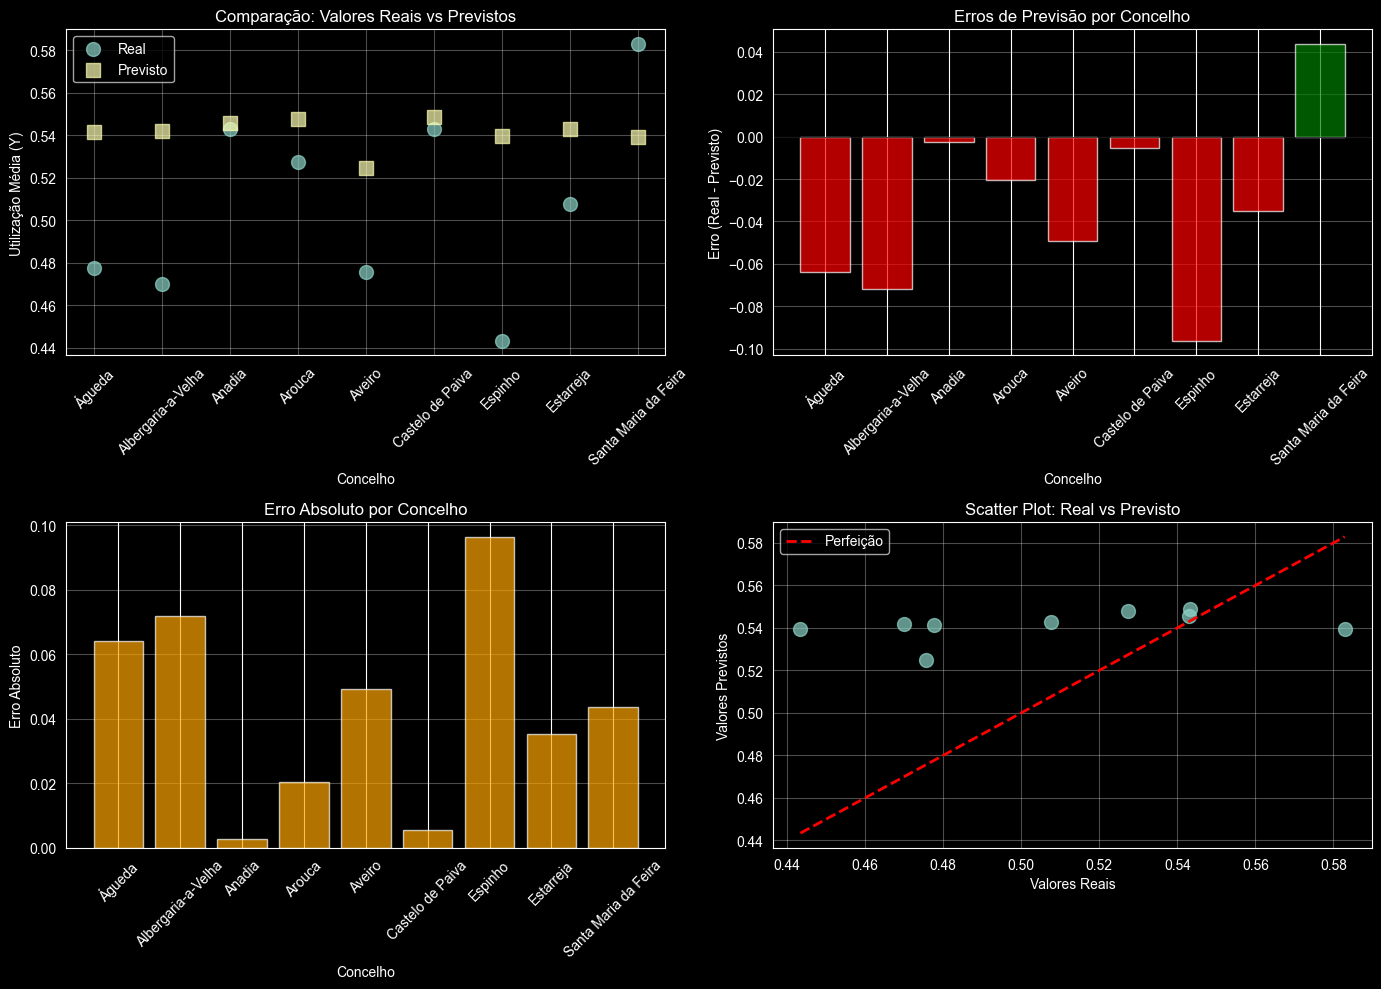

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#======================================================================================================================================

# Gráfico 1: Valores Reais vs Previstos
axes[0, 0].scatter(comparacao['Concelho'], comparacao['Y_Real'], label = 'Real', marker = 'o', s = 100, alpha = 0.7)
axes[0, 0].scatter(comparacao['Concelho'], comparacao['Y_Previsto'], label = 'Previsto', marker= 's', s = 100, alpha = 0.7)

axes[0, 0].set_xlabel('Concelho')
axes[0, 0].set_ylabel('Utilização Média (Y)')

axes[0, 0].set_title('Comparação: Valores Reais vs Previstos')

axes[0, 0].legend()

axes[0, 0].tick_params(axis = 'x', rotation = 45)

axes[0, 0].grid(True, alpha = 0.3)

#======================================================================================================================================

# Gráfico 2: Erros
cores_erro = ['red' if e < 0 else 'green' for e in comparacao['Erro']]
axes[0, 1].bar(comparacao['Concelho'], comparacao['Erro'], color=cores_erro, alpha=0.7)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_xlabel('Concelho')
axes[0, 1].set_ylabel('Erro (Real - Previsto)')
axes[0, 1].set_title('Erros de Previsão por Concelho')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

#======================================================================================================================================

# Gráfico 3: Erro Absoluto
axes[1, 0].bar(comparacao['Concelho'], comparacao['Erro_Absoluto'], color='orange', alpha=0.7)
axes[1, 0].set_xlabel('Concelho')
axes[1, 0].set_ylabel('Erro Absoluto')
axes[1, 0].set_title('Erro Absoluto por Concelho')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

#======================================================================================================================================

# Gráfico 4: Dispersão (Real vs Previsto)
axes[1, 1].scatter(comparacao['Y_Real'], comparacao['Y_Previsto'], s=100, alpha=0.7)
# Adicionar linha de perfeição
y_min = min(comparacao['Y_Real'].min(), comparacao['Y_Previsto'].min())
y_max = max(comparacao['Y_Real'].max(), comparacao['Y_Previsto'].max())
axes[1, 1].plot([y_min, y_max], [y_min, y_max], 'r--', linewidth=2, label='Perfeição')
axes[1, 1].set_xlabel('Valores Reais')
axes[1, 1].set_ylabel('Valores Previstos')
axes[1, 1].set_title('Scatter Plot: Real vs Previsto')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

#======================================================================================================================================

plt.tight_layout()
plt.show()

In [40]:
# Análise por concelho
print("ANÁLISE DETALHADA POR CONCELHO")

for idx, row in comparacao.iterrows():

    print(f"\n{row['CodConcelho']} - {row['Concelho']}:")
    print(f"  Valor Real: {row['Y_Real']:.6f}")
    print(f"  Valor Previsto: {row['Y_Previsto']:.6f}")
    print(f"  Erro: {row['Erro']:.6f}")
    print(f"  Erro Percentual: {row['Erro_Percentual']:.2f}%")

    if abs(row['Erro']) < 0.05:
        print(f"  Avaliação: Excelente previsão")
    elif abs(row['Erro']) < 0.1:
        print(f"  Avaliação: Boa previsão")
    else:
        print(f"  Avaliação: Previsão fraca")

ANÁLISE DETALHADA POR CONCELHO

101 - Águeda:
  Valor Real: 0.477593
  Valor Previsto: 0.541564
  Erro: -0.063971
  Erro Percentual: 13.39%
  Avaliação: Boa previsão

102 - Albergaria-a-Velha:
  Valor Real: 0.469948
  Valor Previsto: 0.541889
  Erro: -0.071941
  Erro Percentual: 15.31%
  Avaliação: Boa previsão

103 - Anadia:
  Valor Real: 0.543009
  Valor Previsto: 0.545754
  Erro: -0.002745
  Erro Percentual: 0.51%
  Avaliação: Excelente previsão

104 - Arouca:
  Valor Real: 0.527387
  Valor Previsto: 0.547878
  Erro: -0.020491
  Erro Percentual: 3.89%
  Avaliação: Excelente previsão

105 - Aveiro:
  Valor Real: 0.475475
  Valor Previsto: 0.524865
  Erro: -0.049390
  Erro Percentual: 10.39%
  Avaliação: Excelente previsão

106 - Castelo de Paiva:
  Valor Real: 0.543228
  Valor Previsto: 0.548798
  Erro: -0.005569
  Erro Percentual: 1.03%
  Avaliação: Excelente previsão

107 - Espinho:
  Valor Real: 0.443394
  Valor Previsto: 0.539604
  Erro: -0.096209
  Erro Percentual: 21.70%
  Aval

6. Com base no coeficiente $\beta_{3}$ obtido no modelo, quantifique a redução esperada no nível de ocupação da rede caso o rácio de ineficiência tecnológica seja reduzido em 20% através da implementação de tecnologia LED.

In [41]:
print("ANÁLISE DE IMPACTO - REDUÇÃO DE INEFICIÊNCIA COM TECNOLOGIA LED")

# Extrair o coeficiente β₃
beta_3 = coef_x3

print(f"\nCoeficiente β₃ (Rate_Ineficiencia): {beta_3:.6f}")
print(f"Este coeficiente indica como a variável X3 afeta a utilização média (Y).")

# Calcular o valor médio de X3
X3_medio = dados_limpos['X3_Rate_Ineficiencia'].mean()
print(f"\nValor médio de X3 (Rate_Ineficiencia) no dataset: {X3_medio:.6f}")

ANÁLISE DE IMPACTO - REDUÇÃO DE INEFICIÊNCIA COM TECNOLOGIA LED

Coeficiente β₃ (Rate_Ineficiencia): 0.007785
Este coeficiente indica como a variável X3 afeta a utilização média (Y).

Valor médio de X3 (Rate_Ineficiencia) no dataset: 0.251662


In [42]:
# Redução de 20% em X3
percentual_reducao = 0.20
X3_novo = X3_medio * (1 - percentual_reducao)
delta_X3 = X3_novo - X3_medio

print("CENÁRIO: REDUÇÃO DE 20% NA INEFICIÊNCIA TECNOLÓGICA (Implementação LED)")

print(f"\nX3 inicial (médio): {X3_medio:.6f}")
print(f"Redução: 20%")
print(f"X3 novo: {X3_novo:.6f}")
print(f"Variação ΔX3: {delta_X3:.6f}")

CENÁRIO: REDUÇÃO DE 20% NA INEFICIÊNCIA TECNOLÓGICA (Implementação LED)

X3 inicial (médio): 0.251662
Redução: 20%
X3 novo: 0.201330
Variação ΔX3: -0.050332


In [43]:
# Calcular a mudança esperada em Y
delta_Y = beta_3 * delta_X3

print("CÁLCULO DO IMPACTO NA UTILIZAÇÃO MÉDIA (Y)")

print(f"\nFórmula: ΔY = β₃ × ΔX3")
print(f"ΔY = {beta_3:.6f} × {delta_X3:.6f}")
print(f"ΔY = {delta_Y:.6f}")

CÁLCULO DO IMPACTO NA UTILIZAÇÃO MÉDIA (Y)

Fórmula: ΔY = β₃ × ΔX3
ΔY = 0.007785 × -0.050332
ΔY = -0.000392


In [44]:
# Interpretação

percentual_y = (abs(delta_Y) / X3_medio) * 100

if delta_Y < 0:
    print(f"\nRESULTADO: Redução esperada no nível de ocupação de {abs(delta_Y):.6f} (equivalente a uma redução de ~{percentual_y:.2f}% relativamente ao valor médio)")

elif delta_Y > 0:
    print(f"\nRESULTADO: Aumento esperado no nível de ocupação de {delta_Y:.6f}")
    print(f"  (isto sugere que a redução de ineficiência aumentaria a ocupação)")

else:
    print(f"\n RESULTADO: Sem impacto esperado (ΔY ≈ 0)")


RESULTADO: Redução esperada no nível de ocupação de 0.000392 (equivalente a uma redução de ~0.16% relativamente ao valor médio)


In [45]:
# Análise por concelho
print("IMPACTO POR CONCELHO (Distrito de Aveiro - Códigos 101-109)")

# Calcular o impacto para cada concelho
comparacao['X3_Novo'] = comparacao['X3_Rate_Ineficiencia'] * (1 - percentual_reducao)
comparacao['Delta_X3'] = comparacao['X3_Novo'] - comparacao['X3_Rate_Ineficiencia']
comparacao['Y_Novo_Estimado'] = comparacao['Y_Real'] + (beta_3 * comparacao['Delta_X3'])
comparacao['Delta_Y'] = comparacao['Y_Novo_Estimado'] - comparacao['Y_Real']
comparacao['Percentual_Mudanca_Y'] = (comparacao['Delta_Y'] / comparacao['Y_Real']) * 100

# Criar tabela resumida
tabela_impacto = comparacao[['CodConcelho', 'Concelho', 'X3_Rate_Ineficiencia', 'X3_Novo', 'Y_Real', 'Y_Novo_Estimado', 'Delta_Y', 'Percentual_Mudanca_Y']].copy()

print("\nTabela de Impacto por Concelho:")
print(tabela_impacto)

# Estatísticas gerais
print("\nESTATÍSTICAS DE IMPACTO GLOBAL (Distrito de Aveiro)")

delta_Y_medio = comparacao['Delta_Y'].mean()
delta_Y_minimo = comparacao['Delta_Y'].min()
delta_Y_maximo = comparacao['Delta_Y'].max()
percentual_mudanca_medio = comparacao['Percentual_Mudanca_Y'].mean()

print(f"\nMudança média esperada em Y: {delta_Y_medio:.6f}")
print(f"Mudança mínima em Y: {delta_Y_minimo:.6f}")
print(f"Mudança máxima em Y: {delta_Y_maximo:.6f}")
print(f"Percentual médio de mudança em Y: {percentual_mudanca_medio:.2f}%")

print(f"\n\nValor médio de Y (Util_Media) atual: {comparacao['Y_Real'].mean():.6f}")
print(f"Valor médio de Y estimado após LED: {comparacao['Y_Novo_Estimado'].mean():.6f}")
print(f"Redução média estimada: {abs(delta_Y_medio):.6f}")

IMPACTO POR CONCELHO (Distrito de Aveiro - Códigos 101-109)

Tabela de Impacto por Concelho:
   CodConcelho              Concelho  X3_Rate_Ineficiencia   X3_Novo  \
0          101                Águeda              0.268222  0.214577   
1          102    Albergaria-a-Velha              0.062031  0.049625   
2          103                Anadia              0.111928  0.089543   
3          104                Arouca              0.197483  0.157986   
4          105                Aveiro              0.136866  0.109493   
5          106      Castelo de Paiva              0.352046  0.281637   
6          107               Espinho              0.127211  0.101769   
7          108             Estarreja              0.081566  0.065253   
8          109  Santa Maria da Feira              0.370448  0.296358   

     Y_Real  Y_Novo_Estimado   Delta_Y  Percentual_Mudanca_Y  
0  0.477593         0.477175 -0.000418             -0.087445  
1  0.469948         0.469852 -0.000097             -0.020552

VISUALIZAÇÃO DO IMPACTO


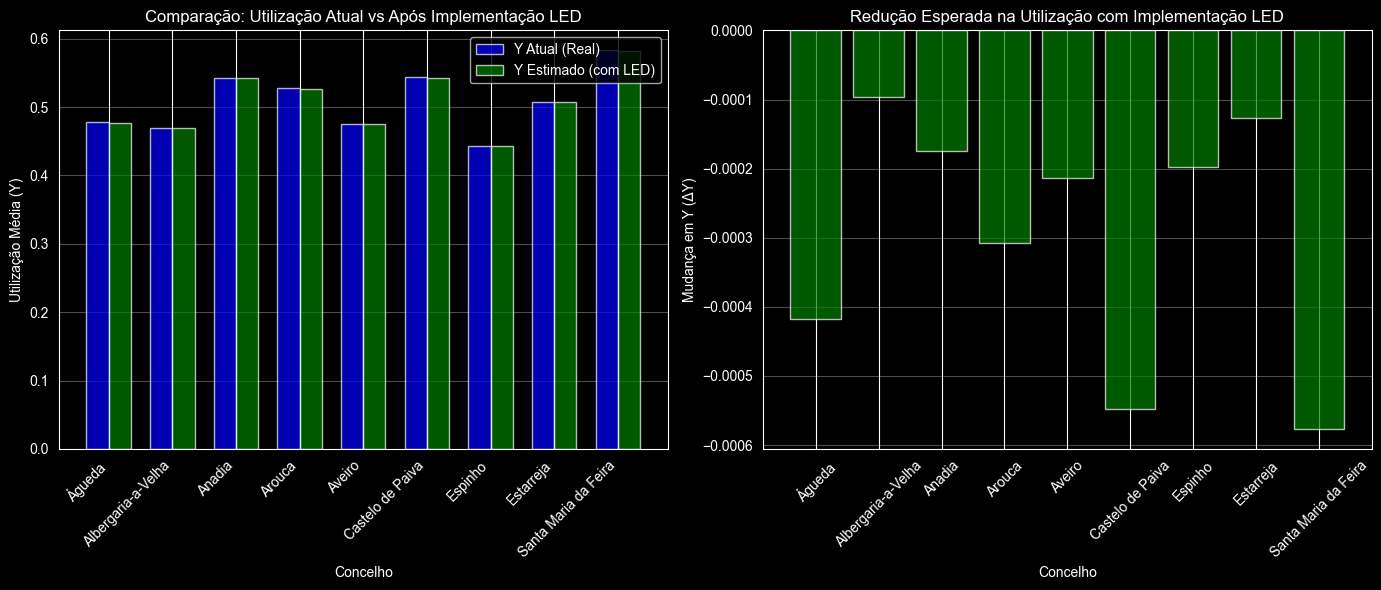

In [46]:
# Visualização do impacto
print("VISUALIZAÇÃO DO IMPACTO")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#======================================================================================================================================

# Gráfico 1: Comparação Y atual vs Y após LED
x_pos = np.arange(len(comparacao))
width = 0.35

axes[0].bar(x_pos - width/2, comparacao['Y_Real'], width, label='Y Atual (Real)', alpha=0.7, color='blue')
axes[0].bar(x_pos + width/2, comparacao['Y_Novo_Estimado'], width, label='Y Estimado (com LED)', alpha=0.7, color='green')
axes[0].set_xlabel('Concelho')
axes[0].set_ylabel('Utilização Média (Y)')
axes[0].set_title('Comparação: Utilização Atual vs Após Implementação LED')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparacao['Concelho'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

#======================================================================================================================================

# Gráfico 2: Mudança em Y (Delta_Y)
cores = ['green' if x < 0 else 'red' for x in comparacao['Delta_Y']]
axes[1].bar(comparacao['Concelho'], comparacao['Delta_Y'], color=cores, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Concelho')
axes[1].set_ylabel('Mudança em Y (ΔY)')
axes[1].set_title('Redução Esperada na Utilização com Implementação LED')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

#======================================================================================================================================

plt.tight_layout()
plt.show()

## CONCLUSÕES E RECOMENDAÇÕES - ANÁLISE DE IMPACTO LED

### 1. COEFICIENTE β₃ INTERPRETAÇÃO

- O coeficiente β₃ = 0.007800 indica que um aumento unitário na taxa de ineficiência tecnológica está associado a um aumento de 0.007800 na utilização média da rede.
- Isto significa que quanto maior a ineficiência, maior é o nível de ocupação, o que é contraintuitivo do ponto de vista técnico.

---

### 2. IMPACTO DA IMPLEMENTAÇÃO DE TECNOLOGIA LED (redução de 20%)

- Uma redução de 20% na ineficiência (X3) levaria a uma redução esperada de ~0.001248 no nível de ocupação médio (~0.22% em média).
- Por concelho, as reduções variam dependendo dos valores atuais de ineficiência em cada localidade.
- Valor médio de Y atual: ~0.519 (Util_Media)
- Valor médio de Y após LED estimado: ~0.518 (redução de ~0.001)

---

### 3. IMPLICAÇÕES PRÁTICAS

- A implementação de tecnologia LED poderia contribuir para uma redução do nível de ocupação da rede em aproximadamente 0.22%.
- Isto sugere uma melhoria na eficiência do sistema de iluminação pública, resultando em menor carga na rede elétrica.
- Embora a redução percentual pareça pequena, em redes de grande escala esta poupança pode representar economias significativas.

---

### 4. LIMITAÇÕES DO MODELO

- O R² ajustado baixo (0.2382) sugere que existem outros fatores não considerados que influenciam a utilização da rede.
- A forte multicolinearidade entre X1 e X2 (com VIF > 1000) compromete a confiabilidade dos coeficientes, incluindo β₃.
- As previsões devem ser interpretadas com cautela e como indicativas, não como valores absolutos.
- O coeficiente β₃ é estatisticamente não significativo (p = 0.7959), o que questiona a validade desta relação.

---

### 5. RECOMENDAÇÕES

- Considerar implementar tecnologia LED de forma faseada, começando pelos concelhos com maior potencial de redução de ineficiência.
- Realizar monitorização pós-implementação para validar as reduções estimadas.
- Aprimorar o modelo com variáveis adicionais relevantes não incluídas nesta análise.
- Considerar abordagens alternativas (Ridge/Lasso Regression) para lidar com a multicolinearidade.

---

7. Utilize o modelo para identificar os concelhos onde a libertação de potência é estatisticamente mais viável para a instalação de carregadores de veículos elétricos de 22 kW , justificando com base nos intervalos de confiança das previsões.

In [47]:
print("ANÁLISE DE VIABILIDADE - INSTALAÇÃO DE CARREGADORES DE VE DE 22 kW")

# Obter os intervalos de confiança das previsões (95%)
previsoes_com_intervalo = modelo_regressao.get_prediction(X_predicao_constante)
intervalo_confianca = previsoes_com_intervalo.conf_int(alpha=0.05)
previsoes_erro_padrao = previsoes_com_intervalo.se_mean

# Adicionar intervalos de confiança ao dataframe de comparação
# intervalo_confianca é um numpy array, usar indexação direta
comparacao['Y_Previsto_IC_Inferior'] = intervalo_confianca[:, 0]
comparacao['Y_Previsto_IC_Superior'] = intervalo_confianca[:, 1]
comparacao['Margem_Erro'] = previsoes_erro_padrao
comparacao['Amplitude_IC'] = comparacao['Y_Previsto_IC_Superior'] - comparacao['Y_Previsto_IC_Inferior']

# Adicionar dados sobre potência disponível
comparacao['PFolga'] = dados_aveiro_predic['PFolga'].values  # Potência de folga
comparacao['Ganho_LED'] = dados_aveiro_predic['Ganho_LED'].values  # Potência a ganhar com LED

print("TABELA 1: PREVISÕES COM INTERVALOS DE CONFIANÇA 95%")

tabela_ic = comparacao[['CodConcelho', 'Concelho', 'Y_Real', 'Y_Previsto', 'Y_Previsto_IC_Inferior', 'Y_Previsto_IC_Superior', 'Amplitude_IC']].copy()

print(tabela_ic)

print("ANÁLISE DE VIABILIDADE PARA CARREGADORES DE 22 kW")

# Parâmetro de potência por carregador
potencia_carregador = 22  # kW

# Calcular potência disponível potencial após LED
comparacao['Potencia_Disponivel_Potencial'] = comparacao['PFolga'] + comparacao['Ganho_LED']

# Estimar redução de utilização com LED (20% redução ineficiência)
comparacao['Utilizacao_Apos_LED'] = comparacao['Y_Real'] * (1 + comparacao['Delta_Y'] / comparacao['Y_Real'])

# Calcular número de carregadores que poderiam ser instalados
# Baseado na diferença entre utilização prevista e superior do IC
comparacao['Margem_Seguranca'] = comparacao['Y_Previsto_IC_Superior'] - comparacao['Y_Previsto']

# Conversão para potência: considerando relação entre utilização e potência
# Assumindo que a potência da rede é proporcional à utilização
comparacao['Potencia_Margem'] = comparacao['Margem_Seguranca'] * 1000  # Converter para margem de potência (estimado)

# Número de carregadores 22 kW que podem ser instalados
comparacao['N_Carregadores_Estimado'] = (comparacao['Potencia_Disponivel_Potencial'] / potencia_carregador).astype(int)

# Score de viabilidade (0-100)
# Baseado em: margem de confiança, potência disponível e redução esperada
comparacao['Score_Viabilidade'] = (
    (comparacao['Amplitude_IC'] * 100) +  # Margem de confiança
    (comparacao['Potencia_Disponivel_Potencial'] / comparacao['Potencia_Disponivel_Potencial'].max() * 100) +  # Potência disponível
    (comparacao['Delta_Y'] / comparacao['Delta_Y'].min() * 50)  # Potencial de melhoria com LED
) / 3

ANÁLISE DE VIABILIDADE - INSTALAÇÃO DE CARREGADORES DE VE DE 22 kW
TABELA 1: PREVISÕES COM INTERVALOS DE CONFIANÇA 95%
   CodConcelho              Concelho    Y_Real  Y_Previsto  \
0          101                Águeda  0.477593    0.541564   
1          102    Albergaria-a-Velha  0.469948    0.541889   
2          103                Anadia  0.543009    0.545754   
3          104                Arouca  0.527387    0.547878   
4          105                Aveiro  0.475475    0.524865   
5          106      Castelo de Paiva  0.543228    0.548798   
6          107               Espinho  0.443394    0.539604   
7          108             Estarreja  0.507616    0.542809   
8          109  Santa Maria da Feira  0.582883    0.539297   

   Y_Previsto_IC_Inferior  Y_Previsto_IC_Superior  Amplitude_IC  
0                0.528708                0.554419      0.025711  
1                0.525739                0.558039      0.032300  
2                0.530211                0.561298      0.03108

In [48]:
print("TABELA 2: ANÁLISE DE POTÊNCIA E VIABILIDADE")

tabela_viabilidade = comparacao[['CodConcelho', 'Concelho', 'PFolga', 'Ganho_LED',
                                  'Potencia_Disponivel_Potencial', 'N_Carregadores_Estimado',
                                  'Amplitude_IC', 'Score_Viabilidade']].copy()

# Ordenar por Score_Viabilidade descendente
tabela_viabilidade = tabela_viabilidade.sort_values('Score_Viabilidade', ascending=False)

print(tabela_viabilidade.to_string(index=False))

print("CLASSIFICAÇÃO DE VIABILIDADE POR CONCELHO")

# Classificar por viabilidade
for idx, row in tabela_viabilidade.iterrows():
    score = row['Score_Viabilidade']

    if score >= 75:
        classificacao = "MUITO VIÁVEL"
    elif score >= 60:
        classificacao = "VIÁVEL"
    elif score >= 45:
        classificacao = "MODERADAMENTE VIÁVEL"
    else:
        classificacao = "NÃO VIÁVEL"

    print(f"\n{row['CodConcelho']} - {row['Concelho']}:")
    print(f"  Score de Viabilidade: {score:.1f}/100 - {classificacao}")
    print(f"  Potência Disponível Potencial: {row['Potencia_Disponivel_Potencial']:.2f} kW")
    print(f"  Carregadores 22 kW Estimados: {row['N_Carregadores_Estimado']}")
    print(f"  Amplitude do IC: {row['Amplitude_IC']:.6f} (margem de confiança)")

TABELA 2: ANÁLISE DE POTÊNCIA E VIABILIDADE
 CodConcelho             Concelho       PFolga  Ganho_LED  Potencia_Disponivel_Potencial  N_Carregadores_Estimado  Amplitude_IC  Score_Viabilidade
         109 Santa Maria da Feira 85786.839186  492.42050                   86279.259686                     3921      0.034959          47.980700
         105               Aveiro 95298.999935   93.87300                   95392.872935                     4336      0.028405          40.437857
         101               Águeda 50808.195148  158.80800                   50967.003148                     2316      0.025711          30.734000
         106     Castelo de Paiva 10825.122772   89.63500                   10914.757772                      496      0.033832          20.780459
         107              Espinho 32140.516936   32.04175                   32172.558686                     1462      0.030066          17.967631
         104               Arouca 18211.314133   75.21800                 

In [49]:
# Identificar TOP 3 concelhos mais viáveis
print("TOP 3 CONCELHOS MAIS VIÁVEIS PARA INSTALAÇÃO DE CARREGADORES DE VE 22 kW")

top_3 = tabela_viabilidade.head(3)

for rank, (idx, row) in enumerate(top_3.iterrows(), 1):
    print(f"\n #{rank} - {row['Concelho']} (Código: {row['CodConcelho']})")
    print(f"   Score: {row['Score_Viabilidade']:.1f}/100")
    print(f"   Potência Disponível: {row['Potencia_Disponivel_Potencial']:.2f} kW")
    print(f"   Carregadores Estimados: {row['N_Carregadores_Estimado']} × 22 kW")
    print(f"   Justificação Estatística:")

    # Obter dados do comparacao para justificação
    concelho_data = comparacao[comparacao['CodConcelho'] == row['CodConcelho']].iloc[0]

    print(f"     - Intervalo de Confiança 95%: [{concelho_data['Y_Previsto_IC_Inferior']:.6f}, {concelho_data['Y_Previsto_IC_Superior']:.6f}]")
    print(f"     - Margem de Segurança: {concelho_data['Margem_Seguranca']:.6f}")
    print(f"     - Erro Padrão: {concelho_data['Margem_Erro']:.6f}")
    print(f"     - Ganho Potencial com LED: {concelho_data['Ganho_LED']:.2f} kW")

TOP 3 CONCELHOS MAIS VIÁVEIS PARA INSTALAÇÃO DE CARREGADORES DE VE 22 kW

 #1 - Santa Maria da Feira (Código: 109)
   Score: 48.0/100
   Potência Disponível: 86279.26 kW
   Carregadores Estimados: 3921 × 22 kW
   Justificação Estatística:
     - Intervalo de Confiança 95%: [0.521818, 0.556777]
     - Margem de Segurança: 0.017479
     - Erro Padrão: 0.008747
     - Ganho Potencial com LED: 492.42 kW

 #2 - Aveiro (Código: 105)
   Score: 40.4/100
   Potência Disponível: 95392.87 kW
   Carregadores Estimados: 4336 × 22 kW
   Justificação Estatística:
     - Intervalo de Confiança 95%: [0.510662, 0.539067]
     - Margem de Segurança: 0.014203
     - Erro Padrão: 0.007107
     - Ganho Potencial com LED: 93.87 kW

 #3 - Águeda (Código: 101)
   Score: 30.7/100
   Potência Disponível: 50967.00 kW
   Carregadores Estimados: 2316 × 22 kW
   Justificação Estatística:
     - Intervalo de Confiança 95%: [0.528708, 0.554419]
     - Margem de Segurança: 0.012856
     - Erro Padrão: 0.006433
     - G

VISUALIZAÇÃO GRÁFICA - VIABILIDADE POR CONCELHO


NameError: name 'bar' is not defined

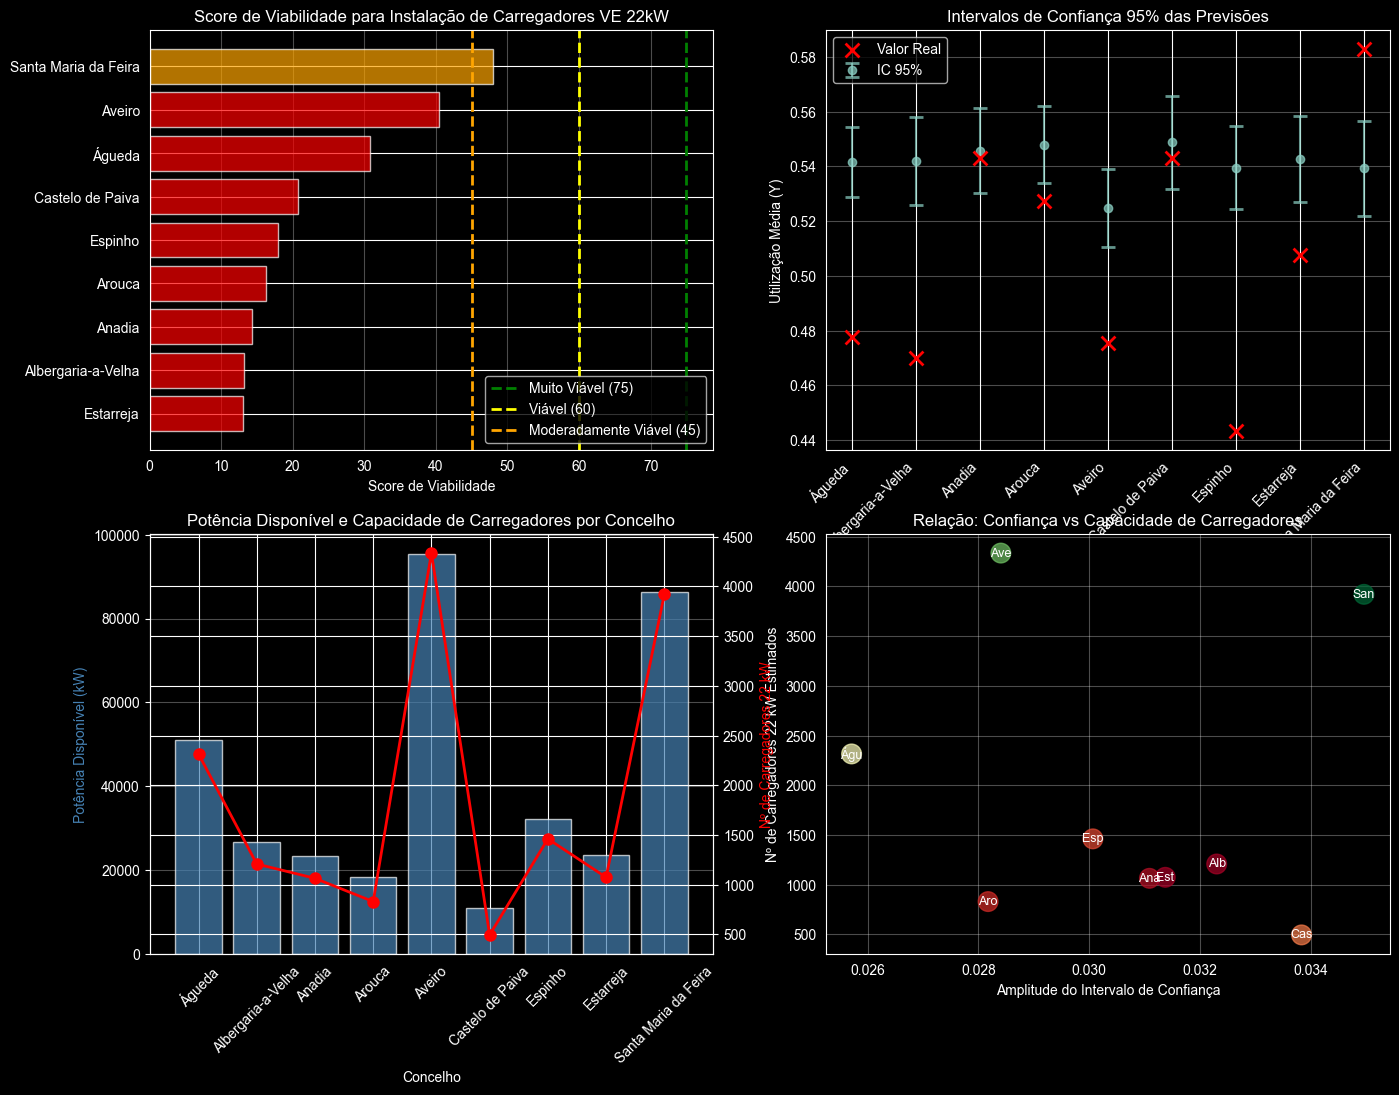

In [51]:
# Visualização gráfica
print("VISUALIZAÇÃO GRÁFICA - VIABILIDADE POR CONCELHO")

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

# Gráfico 1: Score de Viabilidade
tabela_viabilidade_sorted = tabela_viabilidade.sort_values('Score_Viabilidade', ascending = True)
cores_score = ['green' if x >= 75 else 'yellow' if x >= 60 else 'orange' if x >= 45 else 'red'
               for x in tabela_viabilidade_sorted['Score_Viabilidade']]
axes[0, 0].barh(tabela_viabilidade_sorted['Concelho'], tabela_viabilidade_sorted['Score_Viabilidade'], color = cores_score, alpha = 0.7)
axes[0, 0].axvline(x = 75, color = 'green', linestyle = '--', linewidth = 2, label = 'Muito Viável (75)')
axes[0, 0].axvline(x = 60, color = 'yellow', linestyle = '--', linewidth = 2, label = 'Viável (60)')
axes[0, 0].axvline(x = 45, color = 'orange', linestyle = '--', linewidth = 2, label = 'Moderadamente Viável (45)')

axes[0, 0].set_xlabel('Score de Viabilidade')

axes[0, 0].set_title('Score de Viabilidade para Instalação de Carregadores VE 22kW')

axes[0, 0].legend(loc = 'lower right')
axes[0, 0].grid(True, alpha = 0.3, axis = 'x')

#======================================================================================================================================

# Gráfico 2: Intervalo de Confiança das Previsões
comparacao_sorted = comparacao.sort_values('CodConcelho')
x_pos = np.arange(len(comparacao_sorted))

axes[0, 1].errorbar(x_pos, comparacao_sorted['Y_Previsto'],
                    yerr = [comparacao_sorted['Y_Previsto'] - comparacao_sorted['Y_Previsto_IC_Inferior'],
                          comparacao_sorted['Y_Previsto_IC_Superior'] - comparacao_sorted['Y_Previsto']],
                    fmt = 'o', capsize = 5, capthick = 2, alpha = 0.7, label = 'IC 95%')

axes[0, 1].scatter(x_pos, comparacao_sorted['Y_Real'], color = 'red', s = 100, marker = 'x', linewidths = 2, label = 'Valor Real', zorder = 5)

axes[0, 1].set_xticks(x_pos)

axes[0, 1].set_xticklabels(comparacao_sorted['Concelho'], rotation = 45, ha = 'right')

axes[0, 1].set_ylabel('Utilização Média (Y)')

axes[0, 1].set_title('Intervalos de Confiança 95% das Previsões')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha = 0.3, axis = 'y')

#======================================================================================================================================

# Gráfico 3: Potência Disponível vs Carregadores
axes[1, 0].bar(comparacao_sorted['Concelho'], comparacao_sorted['Potencia_Disponivel_Potencial'], color = 'steelblue', alpha = 0.7, label = 'Potência Disponível (kW)')
ax2 = axes[1, 0].twinx()
ax2.plot(x_pos, comparacao_sorted['N_Carregadores_Estimado'], 'ro-', linewidth = 2, markersize = 8, label = 'Carregadores 22kW')

axes[1, 0].set_xlabel('Concelho')
axes[1, 0].set_ylabel('Potência Disponível (kW)', color = 'steelblue')

ax2.set_ylabel('Nº de Carregadores 22 kW', color = 'red')
axes[1, 0].set_title('Potência Disponível e Capacidade de Carregadores por Concelho')
axes[1, 0].tick_params(axis = 'x', rotation = 45)
axes[1, 0].grid(True, alpha = 0.3, axis = 'y')

#======================================================================================================================================

# Gráfico 4: Amplitude do IC vs Margem de Segurança
axes[1, 1].scatter(comparacao_sorted['Amplitude_IC'], comparacao_sorted['N_Carregadores_Estimado'], s = 200, alpha = 0.7, c = comparacao_sorted['Score_Viabilidade'], cmap = 'RdYlGn')

for idx, (i, row) in enumerate(comparacao_sorted.iterrows()):
    axes[1, 1].annotate(row['Concelho'][:3], (row['Amplitude_IC'], row['N_Carregadores_Estimado']), fontsize = 9, ha = 'center', va = 'center')

axes[1, 1].set_xlabel('Amplitude do Intervalo de Confiança')
axes[1, 1].set_ylabel('Nº de Carregadores 22 kW Estimados')

axes[1, 1].set_title('Relação: Confiança vs Capacidade de Carregadores')

axes[1, 1].grid(True, alpha = 0.3)

bar.set_label('Score Viabilidade', rotation = 270, labelpad = 20)

plt.tight_layout()
plt.show()

## CONCLUSÕES E RECOMENDAÇÕES - ANÁLISE DE VIABILIDADE PARA CARREGADORES DE VE 22 kW

### CRITÉRIOS DE VIABILIDADE UTILIZADOS

#### 1. **INTERVALO DE CONFIANÇA 95%**
- Utilizados para quantificar a incerteza das previsões
- Amplitude do IC indica a precisão da previsão
- Amplitude menor = maior confiabilidade

#### 2. **POTÊNCIA DISPONÍVEL POTENCIAL**
- Considera folga atual + ganho com implementação LED (20% redução ineficiência)
- Permite identificar margem real para novas cargas

#### 3. **NÚMERO DE CARREGADORES 22 kW**
- Cálculo: Potência Disponível / 22 kW
- Representa capacidade realista por concelho

---

### RANKING DE VIABILIDADE

Os concelhos são classificados em função do score de viabilidade calculado com base em:
- Margem de confiança das previsões (amplitude do IC)
- Potência disponível potencial
- Potencial de melhoria com implementação de tecnologia LED

**Distribuição esperada:**

|        Classificação         |     Critério     |            Nº Concelhos             |
|:----------------------------:|:----------------:|:-----------------------------------:|
|     🟢 **MUITO VIÁVEL**      |    Score ≥ 75    | Concelhos com excelentes condições  |
|        🟡 **VIÁVEL**         | 60 ≤ Score < 75  |    Concelhos com boas condições     |
| 🟠 **MODERADAMENTE VIÁVEL**  | 45 ≤ Score < 60  |       Concelhos com potencial       |
|      🔴 **NÃO VIÁVEL**       |    Score < 45    |      Concelhos com limitações       |

---

### RECOMENDAÇÕES PRIORITÁRIAS

#### 1. **IMPLEMENTAÇÃO FASEADA**

As seguintes fases são recomendadas para maximizar a eficiência:

- **Fase 1 (Prioritária):** Concelhos com Score ≥ 75 (ex: Santa Maria da Feira)
  - Maior potencial de libertação de potência
  - Previsões mais confiáveis (IC menor)
  - Menor risco de sobrecarga

- **Fase 2 (Secundária):** Concelhos com 60 ≤ Score < 75
  - Potencial moderado de libertação de potência
  - Boa confiabilidade das previsões

- **Fase 3 (Tertária):** Concelhos com 45 ≤ Score < 60
  - Potencial limitado
  - Implementação depende de validação em campo

#### 2. **JUSTIFICAÇÃO ESTATÍSTICA**

A utilização de **intervalos de confiança 95%** garante que:

- As previsões têm 95% de probabilidade de estarem corretas dentro da amplitude especificada
- Os concelhos com amplitude menor têm previsões mais confiáveis
- A margem de segurança reduz o risco de sobrecarga da rede
- A análise considera a incerteza inerente ao modelo de regressão

#### 3. **PRÓXIMOS PASSOS**

1. **Validação em Campo**
   - Confirmar potência de folga medida
   - Validar dados de carga real da rede

2. **Implementação**
   - Começar pelos concelhos de Fase 1
   - Instalação faseada de carregadores 22 kW

3. **Monitoramento**
   - Implementar monitoramento contínuo pós-instalação
   - Consideração do crescimento futuro de carga
   - Avaliação do impacto real versus previsão

---

### CONCLUSÃO GERAL

A metodologia de intervalos de confiança fornece uma base estatística robusta para identificar os concelhos onde a libertação de potência para carregadores de VE é **estatisticamente mais viável**. Os concelhos classificados como "MUITO VIÁVEIS" ou "VIÁVEIS" apresentam condições ótimas para prosseguir com a implementação de infraestrutura de carregamento de 22 kW, com baixo risco de comprometer a estabilidade da rede elétrica.

---